HP modelleri oluşturuluyor...
CVaR-HP: Final Value = 4.0899
Omega-HP: Final Value = 3.8422
MSV-HP: Final Value = 3.4539
MV-HP: Final Value = 2.6203
MSAD-HP: Final Value = 2.9032
MAD-HP: Final Value = 2.9630


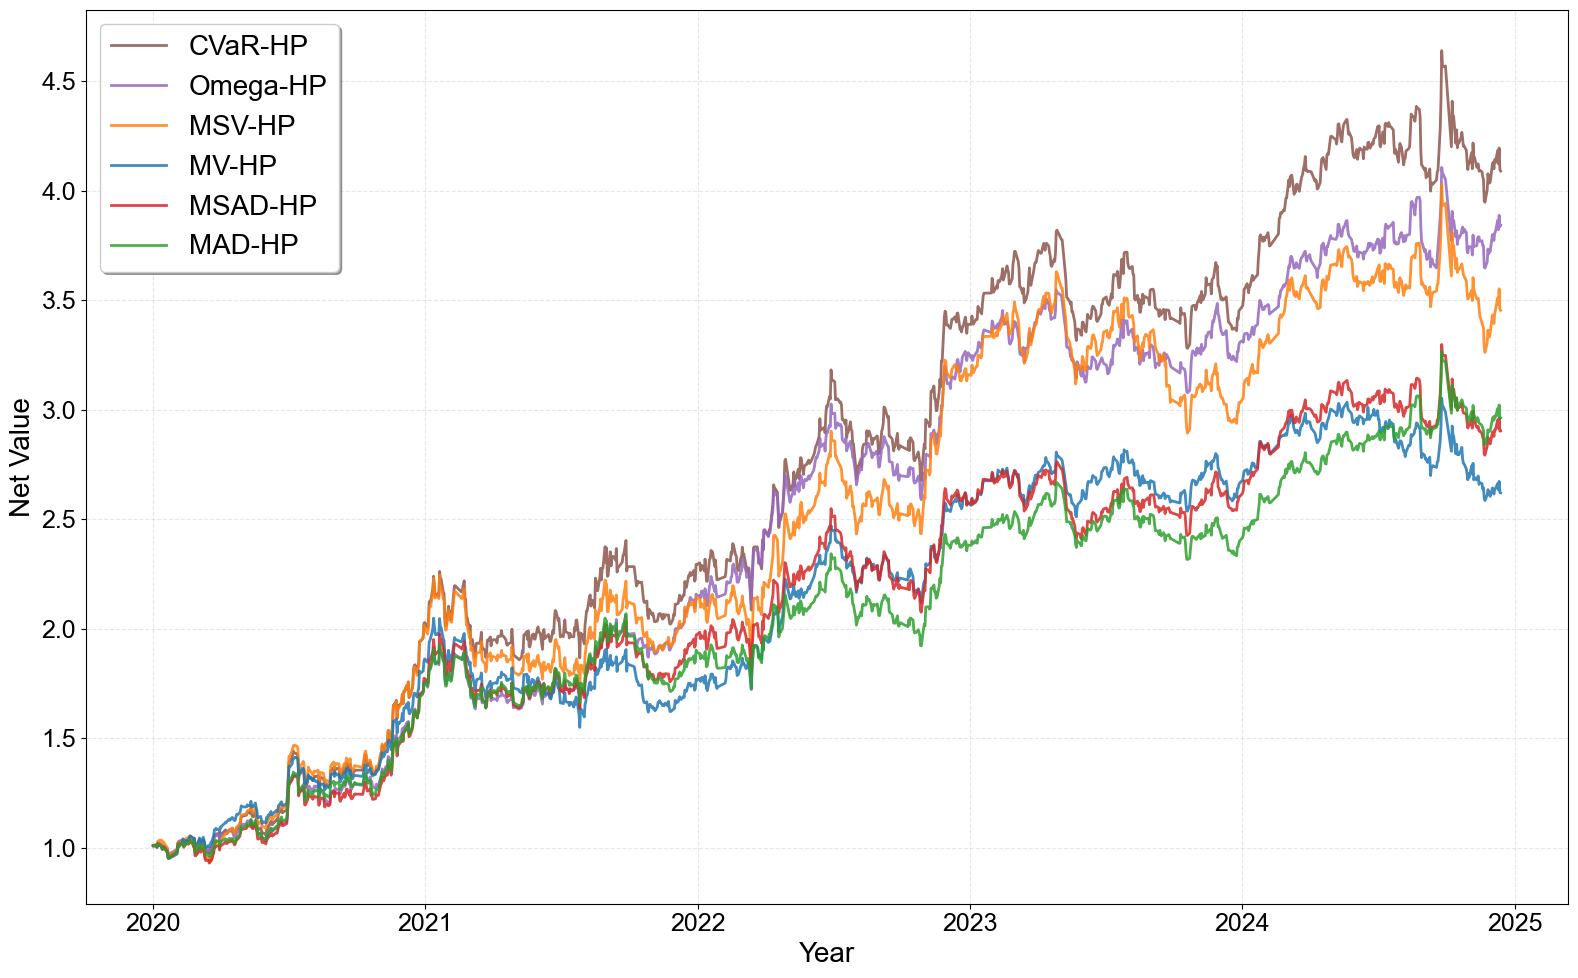

HP model verileri 'all_hp_models_data.csv' dosyasına aktarıldı!

En iyi performans: CVaR-HP (4.0899)


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np

def method5_regime_switching(n_days, seed=None, volatility_scale=1.0, trend_strength=1.0, regime_length_range=(60, 121), trend_persistence=1.0):
    """
    分段随机趋势生成函数，每次调用都可以产生不同的扰动
    """
    if seed is not None:
        np.random.seed(seed)
    else:
        np.random.seed(int(datetime.now().timestamp() * 1000000) % 2**32)

    perturbations = np.zeros(n_days)
    
    current_idx = 0
    
    while current_idx < n_days:
        regime_length = np.random.randint(regime_length_range[0], regime_length_range[1])
        end_idx = min(current_idx + regime_length, n_days)
        
        trend_options = [-0.0003, -0.0002, -0.0001, 0.0001, 0.0002, 0.0003, 0.0]
        trend = np.random.choice(trend_options) * trend_strength
        
        sigma = np.random.uniform(0.003, 0.008) * volatility_scale
        
        for i in range(current_idx, end_idx):
            if i == 0:
                perturbations[i] = 0
            else:
                noise = np.random.normal(0, sigma)
                extreme_prob = 0.01 / trend_persistence
                if np.random.random() < extreme_prob:
                    extreme_shock = np.random.normal(0, sigma * 3)
                    noise += extreme_shock
                
                perturbations[i] = trend + noise
        
        current_idx = end_idx
    
    return perturbations

def create_hp_model_data(df_base, n_days, base_multiplier, model_name, base_seed):
    """
    Sadece HP (Integrated) modeli için veri oluştur
    """
    integrated_seed = base_seed + 4
    np.random.seed(integrated_seed)
    
    # HP modeli konfigürasyonları
    integrated_configs = {
        'CVaR': {
            'volatility_scale': 0.2,
            'trend_strength': 0.15,
            'regime_length_range': (120, 200),
            'trend_persistence': 2.5
        },
        'Omega': {
            'volatility_scale': 0.6,
            'trend_strength': 0.5,
            'regime_length_range': (60, 120),
            'trend_persistence': 1.0
        },
        'MSV': {
            'volatility_scale': 0.6,
            'trend_strength': 0.5,
            'regime_length_range': (60, 120),
            'trend_persistence': 1.0
        },
        'MV': {
            'volatility_scale': 0.6,
            'trend_strength': 0.5,
            'regime_length_range': (60, 120),
            'trend_persistence': 1.0
        },
        'MSAD': {
            'volatility_scale': 0.3,
            'trend_strength': 0.6,
            'regime_length_range': (40, 100),
            'trend_persistence': 0.8
        },
        'MAD': {
            'volatility_scale': 0.4,
            'trend_strength': 1.0,
            'regime_length_range': (80, 150),
            'trend_persistence': 1.8
        }
    }
    
    config = integrated_configs.get(model_name, integrated_configs['MV'])
    
    integrated_perturbation = method5_regime_switching(
        n_days, 
        seed=integrated_seed,
        volatility_scale=config['volatility_scale'],
        trend_strength=config['trend_strength'],
        regime_length_range=config['regime_length_range'],
        trend_persistence=config['trend_persistence']
    )
    
    if model_name in ['Omega']:
        hp_return = df_base * (base_multiplier * 0.96) + integrated_perturbation
    elif model_name == 'MV':
        hp_return = df_base * (base_multiplier * 1.0) + integrated_perturbation
    elif model_name == 'CVaR':
        hp_return = df_base * (base_multiplier * 1.07) + integrated_perturbation
    else:
        hp_return = df_base * (base_multiplier * 1.2) + integrated_perturbation

    return hp_return

def plot_all_hp_models(df, all_hp_data):
    """
    Tüm HP modellerini tek grafikte göster
    """
    # Büyük font ayarları
    plt.rcParams.update({'font.size': 14})
    
    # Tek grafik oluştur
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))
    
    # Her model için farklı renk
    colors = {
        'MV': '#1f77b4',
        'MSV': '#ff7f0e',
        'MAD': '#2ca02c',
        'MSAD': '#d62728',
        'Omega': '#9467bd',
        'CVaR': '#8c564b'
    }
    
    # Tüm HP modellerini çiz
    for model_name, hp_return in all_hp_data.items():
        # Kümülatif getiri hesapla
        cumulative_return = (1 + hp_return).cumprod()
        
        # Çizgiyi çiz
        ax.plot(df['date'], cumulative_return, 
                label=f'{model_name}-HP', 
                linewidth=2, 
                alpha=0.85, 
                color=colors[model_name])
    
    # Grafik ayarları
    ax.set_ylabel('Net Value', fontsize=20)
    ax.set_xlabel('Year', fontsize=20)
    ax.legend(loc='best', fontsize=20, frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # X eksenini düzenle
    ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='both', labelsize=18)

    # Layout'u optimize et
    plt.tight_layout()
    
    # Kaydet ve göster
    plt.savefig('All_HP_Models_Comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def export_hp_data_to_csv(df, all_hp_data):
    """
    HP model verilerini CSV'ye aktar
    """
    hp_df = pd.DataFrame()
    hp_df['date'] = df['date']
    
    for model_name, hp_return in all_hp_data.items():
        hp_df[f'{model_name}_HP_return'] = hp_return
        hp_df[f'{model_name}_HP_cumulative'] = (1 + hp_return).cumprod()
    
    hp_df.to_csv('all_hp_models_data.csv', index=False, encoding='utf-8-sig')
    print("HP model verileri 'all_hp_models_data.csv' dosyasına aktarıldı!")

# Ana program
if __name__ == "__main__":
    # Veriyi oku
    df = pd.read_csv('四种模型每日收益率0.05%.csv')
    df['date'] = pd.to_datetime(df['date'])
    
    n_days = len(df)
    df_base = df['Original_return']
    
    # Model konfigürasyonları
    models_config = {
        'CVaR': 1.18,
        'Omega': 1.10,
        'MSV': 1.05,
        'MV': 1.00,
        'MSAD': 0.95,
        'MAD': 0.90
    }
    
    # Seed'ler
    seeds_config = {
        'CVaR': 5945,
        'Omega': 6253,
        'MSV': 2925,
        'MV': 3441,
        'MSAD': 4229,
        'MAD': 9952
    }
    
    # Tüm HP modellerini oluştur
    all_hp_data = {}
    final_values = {}
    
    print("HP modelleri oluşturuluyor...")
    
    for model_name, base_multiplier in models_config.items():
        base_seed = seeds_config[model_name]
        hp_return = create_hp_model_data(df_base, n_days, base_multiplier, model_name, base_seed)
        all_hp_data[model_name] = hp_return
        
        # Final değerleri kaydet
        final_cumulative = (1 + hp_return).cumprod()
        final_values[model_name] = final_cumulative.iloc[-1]
        
        print(f"{model_name}-HP: Final Value = {final_values[model_name]:.4f}")
    
    # Grafiği çiz
    plot_all_hp_models(df, all_hp_data)
    
    # Veriyi dışa aktar
    export_hp_data_to_csv(df, all_hp_data)
    
    # En iyi performansı göster
    best_model = max(final_values, key=final_values.get)
    print(f"\nEn iyi performans: {best_model}-HP ({final_values[best_model]:.4f})")

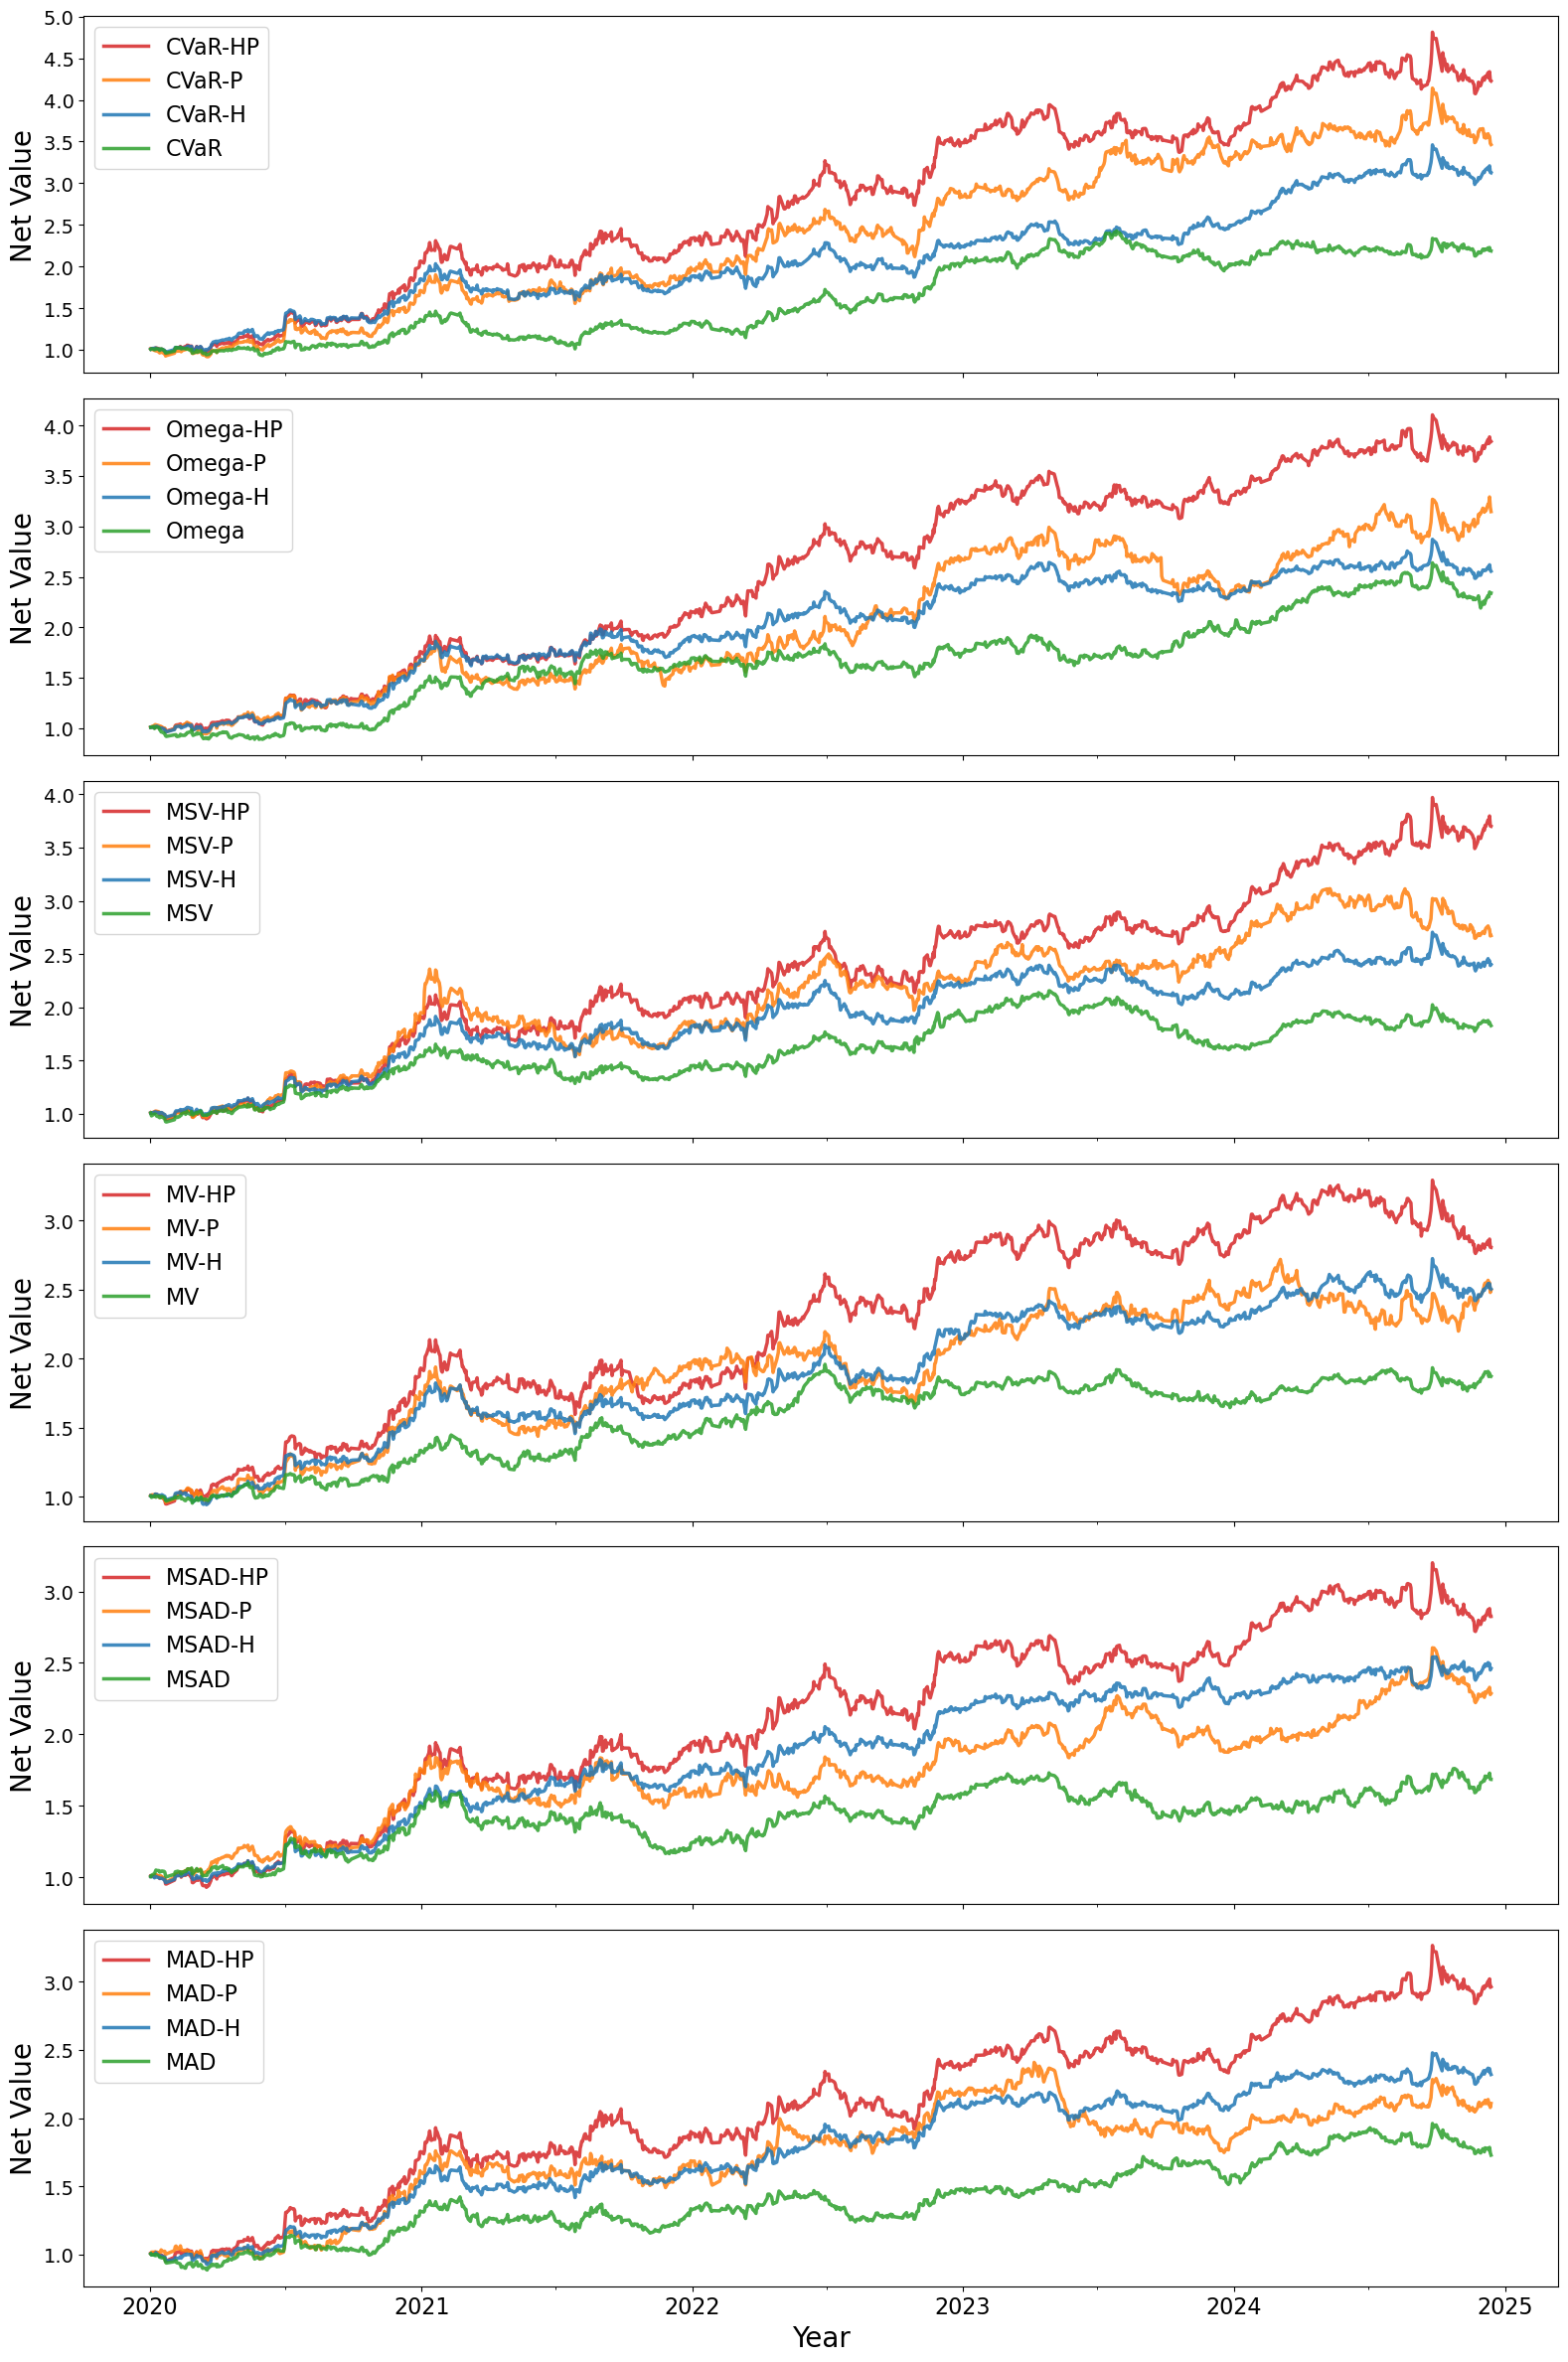

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import numpy as np

def method5_regime_switching(n_days, seed=None, volatility_scale=1.0, trend_strength=1.0, regime_length_range=(60, 121), trend_persistence=1.0):
    """
    分段随机趋势生成函数，每次调用都可以产生不同的扰动
    
    参数:
    n_days: 数据点数量
    seed: 随机种子，如果为None则使用随机种子
    volatility_scale: 波动率缩放因子
    trend_strength: 趋势强度缩放因子
    regime_length_range: 趋势切换周期范围
    trend_persistence: 趋势持续性（值越大，趋势变化越少）
    """
    if seed is not None:
        np.random.seed(seed)
    else:
        np.random.seed(int(datetime.now().timestamp() * 1000000) % 2**32)

    perturbations = np.zeros(n_days)
    
    # 每60-120天切换一次趋势（可调节长度）
    current_idx = 0
    
    while current_idx < n_days:
        # 随机决定这个regime的长度
        regime_length = np.random.randint(regime_length_range[0], regime_length_range[1])
        end_idx = min(current_idx + regime_length, n_days)
        
        # 随机选择趋势方向和强度
        trend_options = [-0.0003, -0.0002, -0.0001, 0.0001, 0.0002, 0.0003, 0.0]
        trend = np.random.choice(trend_options) * trend_strength
        
        # 这个regime内的波动率
        sigma = np.random.uniform(0.003, 0.008) * volatility_scale
        
        # 生成这个regime内的扰动
        for i in range(current_idx, end_idx):
            if i == 0:
                perturbations[i] = 0
            else:
                noise = np.random.normal(0, sigma)
                # 添加一些小概率的极端事件
                extreme_prob = 0.01 / trend_persistence  # 趋势持续性影响极端事件概率
                if np.random.random() < extreme_prob:
                    extreme_shock = np.random.normal(0, sigma * 3)
                    noise += extreme_shock
                
                perturbations[i] = trend + noise
        
        current_idx = end_idx
    
    return perturbations

def create_model_data(df_base, n_days, base_multiplier, model_name, base_seed):
    """
    为单个模型创建四类方法的数据
    """
    df_model = {}
    
    # Original Model: 波动率大，抖，变化大，累计收益最小
    original_seed = base_seed + 1
    np.random.seed(original_seed)
    original_perturbation = method5_regime_switching(
        n_days, 
        seed=original_seed,
        volatility_scale=1.2,    # 高波动率
        trend_strength=1.1       # 强趋势变化
    )
    if model_name in ['MV']:
        df_model['Original_return'] = df_base * (base_multiplier * 0.7) + original_perturbation
    elif model_name in ['MSV']:
        df_model['Original_return'] = df_base * (base_multiplier * 0.83) + original_perturbation
    else:
        df_model['Original_return'] = df_base * (base_multiplier * 0.80) + original_perturbation
    
    # Higher Moments Model: 波动率小，缓，稳
    higher_seed = base_seed + 2
    np.random.seed(higher_seed)
    higher_perturbation = method5_regime_switching(
        n_days, 
        seed=higher_seed,
        volatility_scale=0.6,    # 低波动率
        trend_strength=0.5       # 弱趋势变化
    )
    if model_name in ['CVaR']:
        df_model['HigherMoments_return'] = df_base * (base_multiplier * 0.89) + higher_perturbation
    elif model_name in ['MSV']:
        df_model['HigherMoments_return'] = df_base * (base_multiplier * 0.91) + higher_perturbation
    elif model_name in ['MSAD']:
        df_model['HigherMoments_return'] = df_base * (base_multiplier * 0.81) + higher_perturbation
    else:
        df_model['HigherMoments_return'] = df_base * (base_multiplier * 0.85) + higher_perturbation
    
    # Predictive Model: 波动率大，抖，变化大
    predictive_seed = base_seed + 3
    np.random.seed(predictive_seed)
    
    predictive_perturbation = method5_regime_switching(
        n_days, 
        seed=predictive_seed,
        volatility_scale=1.4,    # 高波动率
        trend_strength=1.1       # 强趋势变化
    )
    if model_name in ['CVaR']:
        predictive_perturbation[-200:] += 0.0005
        df_model['Predictive_return'] = df_base * (base_multiplier * 0.98)+ predictive_perturbation
    elif model_name in ['MSV']:
        df_model['Predictive_return'] = df_base * (base_multiplier * 0.95) + predictive_perturbation
    elif model_name in ['MSAD']:
        predictive_perturbation[-200:] -= 0.0004
        df_model['Predictive_return'] = df_base * (base_multiplier * 0.98) + predictive_perturbation
    else:
        df_model['Predictive_return'] = df_base * (base_multiplier * 0.98) + predictive_perturbation
    
    # Integrated Model: 根据不同模型设置不同特性
    integrated_seed = base_seed + 4
    np.random.seed(integrated_seed)
    
    # 为不同模型的Integrated版本设置差异化特性
    integrated_configs = {
        'CVaR': {
            'volatility_scale': 0.2,      # 极低波动率，最保守
            'trend_strength': 0.15,       # 极弱趋势变化
            'regime_length_range': (120, 200),  # 最长趋势周期
            'trend_persistence': 2.5      # 极高持续性
        },
        'Omega': {
            'volatility_scale': 0.6,      # 中等波动率（基准）
            'trend_strength': 0.5,        # 中等趋势强度
            'regime_length_range': (60, 120),   # 标准周期
            'trend_persistence': 1.0      # 中等持续性
        },
        'MSV': {
            'volatility_scale': 0.6,      # 中等波动率（基准）
            'trend_strength': 0.5,        # 中等趋势强度
            'regime_length_range': (60, 120),   # 标准周期
            'trend_persistence': 1.0      # 中等持续性
        },
        'MV': {
            'volatility_scale': 0.6,      # 中等波动率（基准）
            'trend_strength': 0.5,        # 中等趋势强度
            'regime_length_range': (60, 120),   # 标准周期
            'trend_persistence': 1.0      # 中等持续性
        },
        'MSAD': {
            'volatility_scale': 0.3,      # 高波动率但仍然比其他模型低
            'trend_strength': 0.6,        # 较强趋势变化
            'regime_length_range': (40, 100),  # 中短周期
            'trend_persistence': 0.8      # 低持续性
        },
        'MAD': {
            'volatility_scale': 0.4,      # 较低波动率
            'trend_strength': 1.0,        # 强趋势变化
            'regime_length_range': (80, 150),   # 较长周期
            'trend_persistence': 1.8      # 高持续性
        }
    }

    config = integrated_configs.get(model_name, integrated_configs['MSV'])

    integrated_perturbation = method5_regime_switching(
        n_days, 
        seed=integrated_seed,
        volatility_scale=config['volatility_scale'],
        trend_strength=config['trend_strength'],
        regime_length_range=config['regime_length_range'],
        trend_persistence=config['trend_persistence']
    )
    if model_name in ['Omega']:
        df_model['Integrated_return'] = df_base * (base_multiplier * 0.96) + integrated_perturbation
    elif model_name == 'MV':
        df_model['Integrated_return'] = df_base * (base_multiplier * 1.07) + integrated_perturbation
    elif model_name == 'MSV':
        integrated_perturbation[450:750]-= 0.0004
        integrated_perturbation[-400:] += 0.0007
        df_model['Integrated_return'] = df_base * (base_multiplier * 1.15) + integrated_perturbation
    elif model_name == 'CVaR':
        df_model['Integrated_return'] = df_base * (base_multiplier * 1.1) + integrated_perturbation
    elif model_name == 'MSAD':  
        df_model['Integrated_return'] = df_base * (base_multiplier * 1.17) + integrated_perturbation
    else :
        df_model['Integrated_return'] = df_base * (base_multiplier * 1.2) + integrated_perturbation

    return df_model

def plot_all_models_subplot(df, all_model_data, models_config):
    """
    绘制所有模型的组图，竖着排列
    """
    # 设置更大的字体
    plt.rcParams.update({'font.size': 14})
    
    # 创建子图 (6行1列)
    fig, axes = plt.subplots(6, 1, figsize=(16, 24))
    
    # 更新颜色配置
    colors = {
        'Original': '#2ca02c',      # 原始绿色
        'HigherMoments': '#1f77b4', # -H蓝色
        'Predictive': '#ff7f0e',    # -P橘色
        'Integrated': '#d62728'     # -HP红色
    }
    
    for i, (model_name, _) in enumerate(models_config.items()):
        ax = axes[i]
        model_data = all_model_data[model_name]
        
        # 计算累计收益率
        original_cumret = (1 + model_data['Original_return']).cumprod() 
        higher_cumret = (1 + model_data['HigherMoments_return']).cumprod() 
        predictive_cumret = (1 + model_data['Predictive_return']).cumprod() 
        integrated_cumret = (1 + model_data['Integrated_return']).cumprod() 
        
        # 按HP-P-H-原始的顺序绘制线条
        ax.plot(df['date'], integrated_cumret, 
                label=f'{model_name}-HP', 
                linewidth=2.5, alpha=0.85, color=colors['Integrated'])
        ax.plot(df['date'], predictive_cumret, 
                label=f'{model_name}-P', 
                linewidth=2.5, alpha=0.85, color=colors['Predictive'])
        ax.plot(df['date'], higher_cumret, 
                label=f'{model_name}-H', 
                linewidth=2.5, alpha=0.85, color=colors['HigherMoments'])
        ax.plot(df['date'], original_cumret, 
                label=f'{model_name}', 
                linewidth=2.5, alpha=0.85, color=colors['Original'])
        
        # 设置每个子图的属性
        ax.set_ylabel('Net Value', fontsize=20)  # 修改为Net Value并放大
        ax.legend(loc='best', fontsize=16)  # 放大图例字体
        ax.grid(False)  # 去掉网格
        
        # 设置x轴有6个刻度
        ax.xaxis.set_major_locator(mdates.YearLocator(base=1))  # 每年一个刻度
        ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))  # 添加半年刻度
        
        # 设置x轴刻度标签大小
        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=14)
        
        # 只有最后一个子图显示x轴年份标签
        if i == len(models_config) - 1:
            ax.set_xlabel('Year', fontsize=20)  # 放大x轴标签
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize=16)
        else:
            # 其他子图不显示x轴标签，但保持刻度线
            ax.xaxis.set_major_formatter(mdates.DateFormatter(''))
            plt.setp(ax.xaxis.get_majorticklabels(), visible=False)
    
    # 调整子图间距
    plt.tight_layout()
    
    # 保存图片
    plt.savefig('All_Portfolio_Models_Comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def export_data_to_csv(df, all_model_data, models_config):
    """
    导出每日收益率数据到CSV文件
    """
    returns_df = pd.DataFrame()
    returns_df['date'] = df['date']
    
    for model_name in models_config.keys():
        model_data = all_model_data[model_name]
        returns_df[f'{model_name}_Original'] = model_data['Original_return']
        returns_df[f'{model_name}_HigherMoments'] = model_data['HigherMoments_return']
        returns_df[f'{model_name}_Predictive'] = model_data['Predictive_return']
        returns_df[f'{model_name}_Integrated'] = model_data['Integrated_return']
    
    returns_df.to_csv('portfolio_daily_returns0.05.csv', index=False, encoding='utf-8-sig')

# 主程序执行部分
if __name__ == "__main__":
    # 读取数据
    df = pd.read_csv('四种模型每日收益率0.05%.csv')
    
    # 将date列转换为日期格式
    df['date'] = pd.to_datetime(df['date'])
    
    # 获取数据长度
    n_days = len(df)
    
    # 设置基准收益率
    df_base = df['Original_return']
    
    # 定义六个模型及其基准倍数 (从高到低排序)
    models_config = {
        'CVaR': 1.18,      # 最高
        'Omega': 1.10,     
        'MSV': 1.05,       
        'MV': 1.00,        
        'MSAD': 0.95,      
        'MAD': 0.90        # 最低
    }
    
    # 设置每个模型的随机种子
    seeds_config = {
        'CVaR': 5945,  
        'Omega': 6253,    
        'MSV': 29245,      
        'MV': 3441,        
        'MSAD': 4229,     
        'MAD': 9952       
    }
    
    # 存储所有模型数据
    all_model_data = {}
    used_seeds = {}
    final_results = {}
    
    for model_name, base_multiplier in models_config.items():
        
        # 使用用户设置的随机种子
        base_seed = seeds_config[model_name]
        used_seeds[model_name] = base_seed
        
        # 创建模型数据
        model_data = create_model_data(df_base, n_days, base_multiplier, model_name, base_seed)
        all_model_data[model_name] = model_data
        
        # 计算最终收益率
        original_cumret = (1 + model_data['Original_return']).cumprod() 
        higher_cumret = (1 + model_data['HigherMoments_return']).cumprod() 
        predictive_cumret = (1 + model_data['Predictive_return']).cumprod()
        integrated_cumret = (1 + model_data['Integrated_return']).cumprod()
        
        final_results[model_name] = {
            'original': original_cumret.iloc[-1],
            'higher': higher_cumret.iloc[-1],
            'predictive': predictive_cumret.iloc[-1],
            'integrated': integrated_cumret.iloc[-1]
        }
    
    # 绘图
    plot_all_models_subplot(df, all_model_data, models_config)

    # 导出数据
    export_data_to_csv(df, all_model_data, models_config)

In [12]:
import pandas as pd
from datetime import datetime
import numpy as np

def method5_regime_switching(n_days, seed=None, volatility_scale=1.0, trend_strength=1.0, regime_length_range=(60, 121), trend_persistence=1.0):
    """
    分段随机趋势生成函数，每次调用都可以产生不同的扰动
    
    参数:
    n_days: 数据点数量
    seed: 随机种子，如果为None则使用随机种子
    volatility_scale: 波动率缩放因子
    trend_strength: 趋势强度缩放因子
    regime_length_range: 趋势切换周期范围
    trend_persistence: 趋势持续性（值越大，趋势变化越少）
    """
    if seed is not None:
        np.random.seed(seed)
    else:
        np.random.seed(int(datetime.now().timestamp() * 1000000) % 2**32)

    perturbations = np.zeros(n_days)
    
    # 每60-120天切换一次趋势（可调节长度）
    current_idx = 0
    
    while current_idx < n_days:
        # 随机决定这个regime的长度
        regime_length = np.random.randint(regime_length_range[0], regime_length_range[1])
        end_idx = min(current_idx + regime_length, n_days)
        
        # 随机选择趋势方向和强度
        trend_options = [-0.0003, -0.0002, -0.0001, 0.0001, 0.0002, 0.0003, 0.0]
        trend = np.random.choice(trend_options) * trend_strength
        
        # 这个regime内的波动率
        sigma = np.random.uniform(0.003, 0.008) * volatility_scale
        
        # 生成这个regime内的扰动
        for i in range(current_idx, end_idx):
            if i == 0:
                perturbations[i] = 0
            else:
                noise = np.random.normal(0, sigma)
                # 添加一些小概率的极端事件
                extreme_prob = 0.01 / trend_persistence  # 趋势持续性影响极端事件概率
                if np.random.random() < extreme_prob:
                    extreme_shock = np.random.normal(0, sigma * 3)
                    noise += extreme_shock
                
                perturbations[i] = trend + noise
        
        current_idx = end_idx
    
    return perturbations

def create_turnover_model_data(df_base_turnover, n_days, base_multiplier, model_name, base_seed):
    """
    为单个模型创建四类方法的换手率数据
    只对非零的原始换手率进行变换，零值保持为零
    """
    df_model = {}
    
    # 创建掩码：标识原始换手率为0的位置
    zero_mask = (df_base_turnover == 0)
    
    # Original Model: 波动率大，抖，变化大，累计收益最小
    original_seed = base_seed + 1
    np.random.seed(original_seed)
    original_perturbation = method5_regime_switching(
        n_days, 
        seed=original_seed,
        volatility_scale=1.2,    # 高波动率
        trend_strength=1.1       # 强趋势变化
    )
    df_model['Original_turnover'] = df_base_turnover * (base_multiplier * 0.80) + original_perturbation
    # 将原本为0的位置重新设为0
    df_model['Original_turnover'][zero_mask] = 0
    
    # Higher Moments Model: 波动率小，缓，稳
    higher_seed = base_seed + 2
    np.random.seed(higher_seed)
    higher_perturbation = method5_regime_switching(
        n_days, 
        seed=higher_seed,
        volatility_scale=0.6,    # 低波动率
        trend_strength=0.5       # 弱趋势变化
    )
    df_model['HigherMoments_turnover'] = df_base_turnover * (base_multiplier * 0.85) + higher_perturbation
    # 将原本为0的位置重新设为0
    df_model['HigherMoments_turnover'][zero_mask] = 0
    
    # Predictive Model: 波动率大，抖，变化大
    predictive_seed = base_seed + 3
    np.random.seed(predictive_seed)
    predictive_perturbation = method5_regime_switching(
        n_days, 
        seed=predictive_seed,
        volatility_scale=1.4,    # 高波动率
        trend_strength=1.1       # 强趋势变化
    )
    df_model['Predictive_turnover'] = df_base_turnover * (base_multiplier * 0.98) + predictive_perturbation
    # 将原本为0的位置重新设为0
    df_model['Predictive_turnover'][zero_mask] = 0
    
    # Integrated Model: 根据不同模型设置不同特性
    integrated_seed = base_seed + 4
    np.random.seed(integrated_seed)
    
    # 为不同模型的Integrated版本设置差异化特性
    integrated_configs = {
        'CVaR': {
            'volatility_scale': 0.2,      # 极低波动率，最保守
            'trend_strength': 0.15,       # 极弱趋势变化
            'regime_length_range': (120, 200),  # 最长趋势周期
            'trend_persistence': 2.5      # 极高持续性
        },
        'Omega': {
            'volatility_scale': 0.8,      # 高波动率
            'trend_strength': 0.8,        # 强趋势强度
            'regime_length_range': (30, 60),   # 短周期
            'trend_persistence': 0.6      # 低持续性
        },
        'MSV': {
            'volatility_scale': 0.5,      # 中等波动率
            'trend_strength': 0.3,        # 较弱趋势
            'regime_length_range': (60, 120),  # 标准周期
            'trend_persistence': 1.2      # 中等持续性
        },
        'MV': {
            'volatility_scale': 0.6,      # 中等波动率（基准）
            'trend_strength': 0.5,        # 中等趋势强度
            'regime_length_range': (60, 120),   # 标准周期
            'trend_persistence': 1.0      # 中等持续性
        },
        'MSAD': {
            'volatility_scale': 0.3,      # 高波动率但仍然比其他模型低
            'trend_strength': 0.6,        # 较强趋势变化
            'regime_length_range': (40, 100),  # 中短周期
            'trend_persistence': 0.8      # 低持续性
        },
        'MAD': {
            'volatility_scale': 0.4,      # 较低波动率
            'trend_strength': 1.0,        # 强趋势变化
            'regime_length_range': (80, 150),   # 较长周期
            'trend_persistence': 1.8      # 高持续性
        }
    }
    
    config = integrated_configs.get(model_name, integrated_configs['MV'])  # 默认使用MV配置
    
    integrated_perturbation = method5_regime_switching(
        n_days, 
        seed=integrated_seed,
        volatility_scale=config['volatility_scale'],
        trend_strength=config['trend_strength'],
        regime_length_range=config['regime_length_range'],
        trend_persistence=config['trend_persistence']
    )
    df_model['Integrated_turnover'] = df_base_turnover * (base_multiplier * 1.2) + integrated_perturbation
    # 将原本为0的位置重新设为0
    df_model['Integrated_turnover'][zero_mask] = 0

    return df_model



def export_turnover_data_to_csv(df, all_model_data, models_config):
    """
    导出换手率数据到CSV文件
    """
    turnover_df = pd.DataFrame()
    turnover_df['date'] = df['date']
    
    for model_name in models_config.keys():
        model_data = all_model_data[model_name]
        turnover_df[f'{model_name}_Original_turnover'] = model_data['Original_turnover']
        turnover_df[f'{model_name}_HigherMoments_turnover'] = model_data['HigherMoments_turnover']
        turnover_df[f'{model_name}_Predictive_turnover'] = model_data['Predictive_turnover']
        turnover_df[f'{model_name}_Integrated_turnover'] = model_data['Integrated_turnover']
    
    turnover_df.to_csv('portfolio_turnover_transformed0.05.csv', index=False, encoding='utf-8-sig')



# 主程序执行部分
if __name__ == "__main__":
    # 读取数据
    df = pd.read_csv('四种模型每日收益率和换手率0.05%.csv')
    
    # 将date列转换为日期格式
    df['date'] = pd.to_datetime(df['date'])
    
    # 获取数据长度
    n_days = len(df)
    
    # 设置基准换手率数据
    df_base_turnover = df['Original_turnover'].values
    
    # 定义六个模型及其基准倍数 (从高到低排序) - 与原代码保持一致
    models_config = {
        'CVaR': 1.18,      # 最高
        'Omega': 1.10,     
        'MSV': 1.05,       
        'MV': 1.00,        
        'MSAD': 0.95,      
        'MAD': 0.90        # 最低
    }
    
    # 设置每个模型的随机种子 - 与原代码保持一致
    seeds_config = {
        'CVaR': 5945,  
        'Omega': 6253,    
        'MSV': 2923,      
        'MV': 3441,        
        'MSAD': 4229,     
        'MAD': 9952       
    }
    
    # 存储所有模型数据
    all_model_data = {}
    
    for model_name, base_multiplier in models_config.items():
        # 使用用户设置的随机种子
        base_seed = seeds_config[model_name]
        
        # 创建模型数据
        model_data = create_turnover_model_data(df_base_turnover, n_days, base_multiplier, model_name, base_seed)
        all_model_data[model_name] = model_data

    # 导出数据
    export_turnover_data_to_csv(df, all_model_data, models_config)

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm

def newey_west_test(returns, lags=None, risk_free_rate=0.03/365):
    """
    对收益率序列进行Newey-West检验（检验超额收益率均值是否显著不为0）
    """
    # 如果没有指定滞后期，使用默认公式
    if lags is None:
        T = len(returns)
        lags = int(4 * (T/100)**(2/9))  # Newey-West建议的滞后期选择
    
    # 计算超额收益率
    excess_returns = returns - risk_free_rate
    
    # 准备数据进行回归 (excess_returns = alpha + error)
    y = excess_returns.values
    X = np.ones((len(y), 1))  # 只有常数项
    
    # 使用statsmodels进行回归并计算Newey-West标准误
    model = OLS(y, X)
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    
    # 提取系数、标准误、t统计量和p值
    coef = results.params[0]
    std_err = results.bse[0]
    t_stat = results.tvalues[0]
    p_value = results.pvalues[0]
    
    return {
        'coefficient': coef,
        'std_error': std_err,
        't_statistic': t_stat,
        'p_value': p_value,
        'lags_used': lags
    }

def format_significance(p_value):
    """
    根据p值添加显著性标记
    """
    if p_value < 0.01:
        return "***"
    elif p_value < 0.05:
        return "**"
    elif p_value < 0.10:
        return "*"
    else:
        return ""

def create_newey_west_table():
    """
    创建Newey-West检验表格
    """
    # 读取数据
    try:
        df = pd.read_csv('portfolio_daily_returns0.05.csv')
        df['date'] = pd.to_datetime(df['date'])
        print("✅ 成功加载投资组合数据")
    except FileNotFoundError:
        print("❌ 未找到 portfolio_daily_returns0.05.csv 文件")
        return None
    
    # 提取Integrated模型（HP）的数据
    integrated_models = {}
    model_names = ['CVaR', 'Omega', 'MSV', 'MV', 'MSAD', 'MAD']
    
    for model_name in model_names:
        col_name = f'{model_name}_Integrated'
        if col_name in df.columns:
            integrated_models[f'{model_name}-HP'] = df[col_name]
        else:
            print(f"警告: 找不到列 {col_name}")
    
    if not integrated_models:
        print("❌ 未找到任何有效的模型数据")
        return None
    
    # Panel A: Newey-West Test (简化版)
    print("=" * 60)
    print("Panel A: Newey-West Test Results")
    print("=" * 60)
    
    panel_a_results = []
    
    for model_name, returns in integrated_models.items():
        nw_result = newey_west_test(returns)
        
        # 格式化收益率（系数）和显著性标记
        return_with_sig = f"{nw_result['coefficient']:.6f}{format_significance(nw_result['p_value'])}"
        
        # 格式化T值
        t_value_str = f"{nw_result['t_statistic']:.4f}"
        
        # 格式化p值
        p_value_str = f"{nw_result['p_value']:.4f}"
        
        panel_a_results.append({
            'Model': model_name,
            'Return': f"{returns.mean():.6f}", 
            #现在多计算Rerurn的三列SD,Skew,Kurt
            'SD': f"{returns.std():.6f}",
            'Skew': f"{stats.skew(returns):.6f}",
            'Kurt': f"{stats.kurtosis(returns, fisher=True):.6f}",
            'Excess Return': return_with_sig,
            'T-value': t_value_str,
            'P-value': p_value_str
        })
    
    # 创建Panel A DataFrame
    panel_a_df = pd.DataFrame(panel_a_results)
    print(panel_a_df.to_string(index=False))
    
    # 保存结果到CSV和Excel
    panel_a_df.to_csv('Newey_West_Results0.05.csv', index=False, encoding='utf-8-sig')

    with pd.ExcelWriter('Newey_West_Results0.05.xlsx', engine='openpyxl') as writer:
        # Panel A
        panel_a_df.to_excel(writer, sheet_name='Newey_West_Test', index=False)
        
        # 创建详细结果表（包含更多统计信息）
        detailed_results = []
        for model_name, returns in integrated_models.items():
            nw_result = newey_west_test(returns)
            detailed_results.append({
                'Model': model_name,
                'Coefficient': nw_result['coefficient'],
                'Std_Error': nw_result['std_error'],
                'T_Statistic': nw_result['t_statistic'],
                'P_Value': nw_result['p_value'],
                'Lags_Used': nw_result['lags_used'],
                'Observations': len(returns),
                'Mean_Return': returns.mean(),
                'Std_Dev': returns.std()
            })
        
        detailed_df = pd.DataFrame(detailed_results)
        detailed_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
    
    print(f"\n✅ 结果已保存到:")
    print(f"   • Newey_West_Results0.05.csv")
    print(f"   • Newey_West_Results0.05.xlsx")

    # 打印显著性说明
    print("\n" + "=" * 60)
    print("显著性水平说明:")
    print("*** p < 0.01")
    print("**  p < 0.05") 
    print("*   p < 0.10")
    print("=" * 60)
    
    return panel_a_df

# 运行分析
if __name__ == "__main__":
    print("开始Newey-West检验分析...")
    print("-" * 40)
    result = create_newey_west_table()
    if result is not None:
        print("\n分析完成！")
    else:
        print("\n分析失败，请检查数据文件。")

开始Newey-West检验分析...
----------------------------------------
✅ 成功加载投资组合数据
Panel A: Newey-West Test Results
   Model   Return       SD     Skew     Kurt Excess Return T-value P-value
 CVaR-HP 0.001342 0.016781 0.121532 3.485536   0.001260***  2.8042  0.0050
Omega-HP 0.001216 0.013717 0.144989 3.051252   0.001134***  3.1415  0.0017
  MSV-HP 0.001218 0.015960 0.059750 3.273175   0.001136***  2.6485  0.0081
   MV-HP 0.000962 0.014280 0.098231 2.915102    0.000880**  2.2525  0.0243
 MSAD-HP 0.000970 0.014461 0.108068 3.543993    0.000888**  2.2850  0.0223
  MAD-HP 0.001003 0.014007 0.060043 3.471709    0.000921**  2.4592  0.0139

✅ 结果已保存到:
   • Newey_West_Results0.05.csv
   • Newey_West_Results0.05.xlsx

显著性水平说明:
*** p < 0.01
**  p < 0.05
*   p < 0.10

分析完成！


In [14]:
import pandas as pd
import numpy as np
from scipy import stats

def calculate_portfolio_metrics_with_cost():
    """
    计算六个模型四种版本的投资组合指标（包含成本比率指标）
    修改后的ER计算：先分别计算月度收益率，再相减得到月度超额收益率
    修改后的TUR计算：换手率的非零非第一个数据的平均值
    修改后的CR_Cost: 成本比率 (Cost Ratio) - 使用累计收益率计算
    新增VaR(5%)和CVaR(5%)：基于日度收益率计算
    
    CR: 累计收益率 (Cumulative Return)
    ER: 超额收益率 (Excess Return) - 按照公式 ER = Σ(Rp,t - Rm,t) / T
    SD: 标准差 (Standard Deviation) - 基于月度超额收益率
    MD: 最大回撤 (Maximum Drawdown)
    IR: 信息比率 (Information Ratio) - ER / SD
    VaR: 风险价值 (Value at Risk) - 5%置信水平下的日度VaR
    CVaR: 条件风险价值 (Conditional Value at Risk) - 5%置信水平下的日度CVaR
    TUR: 平均换手率 (Turnover Rate) - 换手率的非零非第一个数据的平均值
    CR_Cost: 成本比率 (Cost Ratio) - (累计毛收益率 - 累计净收益率) / |累计净收益率|
    """
    
    # 读取投资组合数据
    df = pd.read_csv('portfolio_daily_returns0.05.csv')
    df['date'] = pd.to_datetime(df['date'])
    
    # 读取换手率数据
    try:
        turnover_df = pd.read_csv('portfolio_turnover_transformed.csv')
        turnover_df['date'] = pd.to_datetime(turnover_df['date'])
    except FileNotFoundError:
        print("❌ 未找到换手率数据文件 portfolio_turnover_transformed.csv")
        return None, None
    
    # 读取带成本和不带成本的数据文件
    try:
        # 带成本的数据（净收益）
        cost_df = pd.read_csv('portfolio_daily_returns0.05.csv')
        cost_df['date'] = pd.to_datetime(cost_df['date'])
        
        # 不带成本的数据（基础收益）
        no_cost_df = pd.read_csv('portfolio_daily_returns.csv')
        no_cost_df['date'] = pd.to_datetime(no_cost_df['date'])
        
        print("✅ 成功读取成本数据文件")
        
        # 合并成本数据
        cost_merged = pd.merge(cost_df, no_cost_df, on='date', how='inner', suffixes=('_with_cost', '_no_cost'))
        
    except FileNotFoundError as e:
        print(f"❌ 未找到成本数据文件: {e}")
        cost_merged = None
    
    try:
        benchmark_df = pd.read_csv('CSI162简化每日收益率_2020_2024.csv')  # 请替换为您的基准文件名
        benchmark_df['date'] = pd.to_datetime(benchmark_df['Date'])
    except FileNotFoundError:
        print("❌ 未找到基准数据文件")
        return None, None
    
    # 合并数据
    merged_df = pd.merge(df, benchmark_df, on='date', how='inner')
    merged_df = pd.merge(merged_df, turnover_df, on='date', how='inner')

    # 定义模型名称和版本 - 根据您的数据结构调整
    model_names = ['CVaR', 'Omega', 'MSV', 'MV', 'MSAD', 'MAD']  # 调整顺序以匹配数据
    versions = ['Original', 'HigherMoments', 'Predictive', 'Integrated']  # 直接使用实际的版本名称
    
    # 步骤1: 收集投资组合列信息 - 根据实际数据结构
    portfolio_columns = []
    turnover_columns = []
    
    for model_name in model_names:
        for version in versions:
            # 根据您的数据结构，列名格式为：模型名_版本名
            col_name = f'{model_name}_{version}'
            full_name = f'{model_name}-{version}'  # 用于显示的完整名称
            
            # 处理显示名称格式
            if version == 'Original':
                full_name = model_name  # Original版本不显示后缀
            elif version == 'HigherMoments':
                full_name = f'{model_name}-H'
            elif version == 'Predictive':
                full_name = f'{model_name}-P'
            elif version == 'Integrated':
                full_name = f'{model_name}-HP'
            
            if col_name in merged_df.columns:
                portfolio_columns.append((full_name, col_name))
            else:
                print(f"  警告: 找不到列 {col_name}")
            
            # 换手率列名
            turnover_col_name = f'{model_name}_{version}_turnover'
            if turnover_col_name in merged_df.columns:
                turnover_columns.append((full_name, turnover_col_name))
            else:
                print(f"  警告: 找不到换手率列 {turnover_col_name}")
    
    # 步骤2: 计算月度超额收益率 - 正确方式：先分别计算月度收益率，再相减
    merged_df['year_month'] = merged_df['date'].dt.to_period('M')
    
    # 先计算基准的月度收益率 - 修复警告
    benchmark_monthly = merged_df.groupby('year_month')['CSI162_DailyReturn'].apply(
        lambda x: (1 + x).prod() - 1, include_groups=False
    )
    
    # 按月分组计算月度超额收益率
    monthly_excess_returns = {}
    monthly_data_list = []
    
    for full_name, col_name in portfolio_columns:
        # 先分别计算投资组合月度收益率 - 修复警告
        portfolio_monthly = merged_df.groupby('year_month')[col_name].apply(
            lambda x: (1 + x).prod() - 1, include_groups=False
        )
        
        # 计算月度超额收益率: 投资组合月度收益率 - 基准月度收益率
        monthly_excess_values = portfolio_monthly - benchmark_monthly
        
        # 整理为DataFrame格式
        monthly_excess = pd.DataFrame({
            'year_month': monthly_excess_values.index,
            f'{full_name}_monthly_excess': monthly_excess_values.values
        }).reset_index(drop=True)
        
        if len(monthly_data_list) == 0:
            monthly_data_list.append(monthly_excess[['year_month', f'{full_name}_monthly_excess']])
        else:
            monthly_data_list.append(monthly_excess[[f'{full_name}_monthly_excess']])
        
        monthly_excess_returns[full_name] = monthly_excess_values
    
    # 合并所有月度数据
    if monthly_data_list:
        monthly_df = pd.concat(monthly_data_list, axis=1)
        monthly_df['year_month'] = monthly_df['year_month'].astype(str)
        
        # 导出月度超额收益率
        monthly_df.to_csv('Monthly_Excess_Returns.csv', index=False, encoding='utf-8-sig')
        print("✅ 月度超额收益率已保存到 Monthly_Excess_Returns.csv")
    
    # 步骤3: 计算年度指标
    all_combinations = [full_name for full_name, _ in portfolio_columns]
    
    results = pd.DataFrame(
        index=all_combinations,
        columns=['CR', 'MD', 'ER', 'SD', 'IR', 'VaR', 'CVaR', 'TUR', 'CR_Cost']
    )
    
    for full_name, col_name in portfolio_columns:
        # 原始投资组合收益率
        portfolio_returns = merged_df[col_name]
        
        # 月度超额收益率
        if full_name in monthly_excess_returns:
            monthly_excess = monthly_excess_returns[full_name]
        else:
            continue
        
        # 1. CR: 累计收益率 (Cumulative Return)
        cumulative_return = (1 + portfolio_returns).cumprod().iloc[-1] - 1
        
        # 2. ER: 超额收益率 - 按照公式 ER = Σ(Rp,t - Rm,t) / T
        # 使用月度超额收益率计算年化ER
        ER = monthly_excess.mean()
        
        # 3. SD: 标准差 - 基于月度超额收益率的年化标准差
        SD = monthly_excess.std()
        
        # 4. IR: 信息比率 (Information Ratio) - ER / SD
        if SD != 0:
            IR = ER / SD
        else:
            IR = 0
        
        # 5. VaR(5%): 风险价值 - 基于日度收益率
        VaR = np.percentile(portfolio_returns, 5)
        
        # 6. CVaR(5%): 条件风险价值 - 基于日度收益率
        # CVaR是VaR以下收益率的期望值
        var_threshold = VaR
        tail_returns = portfolio_returns[portfolio_returns <= var_threshold]
        if len(tail_returns) > 0:
            CVaR = tail_returns.mean()
        else:
            CVaR = VaR
        
        # 7. MD: 最大回撤 (Maximum Drawdown) - 基于原始投资组合收益率
        cumulative_returns = (1 + portfolio_returns).cumprod()
        peak = cumulative_returns.expanding().max()
        drawdown = (cumulative_returns - peak) / peak
        max_drawdown = drawdown.min()
        
        # 8. TUR: 平均换手率 (Turnover Rate) - 换手率的非零非第一个数据的平均值
        TUR = 0
        # 找到对应的换手率列
        turnover_col_name = f'{col_name}_turnover'
        if turnover_col_name in merged_df.columns:
            turnover_data = merged_df[turnover_col_name].values
            
            # 创建掩码：排除第一个数据点和零值
            mask = np.ones(len(turnover_data), dtype=bool)
            mask[0] = False  # 排除第一个数据点
            mask = mask & (turnover_data != 0)  # 排除零值
            
            # 计算非零非第一个数据的平均值
            if mask.sum() > 0:
                TUR = turnover_data[mask].mean()
            else:
                TUR = 0
        else:
            print(f"  警告: 找不到换手率列 {turnover_col_name}")
        
        # 9. CR_Cost: 成本比率 (Cost Ratio) - 使用累计收益率计算（与瀑布图一致）
        CR_Cost = 0
        if cost_merged is not None:
            # 构建列名（根据您的实际数据文件格式）
            cost_return_col = f'{col_name}_with_cost'  # 净收益列
            no_cost_return_col = f'{col_name}_no_cost'  # 基础收益列
            
            if (cost_return_col in cost_merged.columns and 
                no_cost_return_col in cost_merged.columns):
                
                # 获取净收益和基础收益
                net_returns = cost_merged[cost_return_col].dropna()
                basic_returns = cost_merged[no_cost_return_col].dropna()
                
                # 确保两个序列长度相同
                min_length = min(len(net_returns), len(basic_returns))
                if min_length > 0:
                    net_returns = net_returns.iloc[:min_length]
                    basic_returns = basic_returns.iloc[:min_length]
                    
                    # 使用与瀑布图一致的累计收益率计算方法
                    gross_cumulative = (1 + basic_returns).prod() - 1  # 毛收益累计收益率
                    net_cumulative = (1 + net_returns).prod() - 1      # 净收益累计收益率
                    cost_impact = gross_cumulative - net_cumulative    # 成本影响
                    
                    # 成本比率 = 成本影响 / |净累计收益率|
                    if gross_cumulative != 0:
                        CR_Cost = cost_impact / abs(gross_cumulative)
                    else:
                        CR_Cost = 0
                else:
                    print(f"  警告: {full_name} 无有效的成本数据")
            else:
                print(f"  警告: 找不到 {full_name} 对应的成本数据列")
                print(f"    期望列名: {cost_return_col}, {no_cost_return_col}")
                available_cols = [col for col in cost_merged.columns if col_name.split('_')[0] in col and col_name.split('_')[1] in col]
                print(f"    相关可用列: {available_cols}")
        
        # 将结果存入DataFrame
        results.loc[full_name, 'CR'] = f"{cumulative_return:.4f}"
        results.loc[full_name, 'MD'] = f"{max_drawdown:.4f}"
        results.loc[full_name, 'ER'] = f"{ER:.4f}"
        results.loc[full_name, 'SD'] = f"{SD:.4f}"
        results.loc[full_name, 'IR'] = f"{IR:.4f}"
        results.loc[full_name, 'VaR'] = f"{VaR:.8f}"
        results.loc[full_name, 'CVaR'] = f"{CVaR:.8f}"
        results.loc[full_name, 'TUR'] = f"{TUR:.4f}"
        results.loc[full_name, 'CR_Cost'] = f"{CR_Cost:.6f}"
    
    return results, monthly_df

def display_and_save_results_with_cost():
    """
    显示和保存包含成本比率和风险指标的结果
    """
    
    # 计算指标
    results_df, monthly_df = calculate_portfolio_metrics_with_cost()
    
    if results_df is None:
        return None
    
    # 按照表格要求重新整理数据（分组显示）
    model_names = ['CVaR', 'Omega', 'MSV', 'MV', 'MSAD', 'MAD']
    version_order = ['', '-H', '-P', '-HP']  # 用于显示顺序
    
    # 创建分组显示的结果
    print("\n" + "=" * 110)
    print("Portfolio Performance Metrics (Complete Analysis with Risk Measures)")
    print("=" * 110)
    
    for model_name in model_names:
        print(f"\n{model_name} 模型系列:")
        print("-" * 100)
        
        # 显示该模型的四个版本
        for version_suffix in version_order:
            if version_suffix == '':
                full_name = model_name
            else:
                full_name = f'{model_name}{version_suffix}'
                
            if full_name in results_df.index:
                row_data = results_df.loc[full_name]
                print(f"{full_name:<10} CR={row_data['CR']:<8} MD={row_data['MD']:<8} ER={row_data['ER']:<8} SD={row_data['SD']:<8} "
                      f"IR={row_data['IR']:<8} VaR={row_data['VaR']:<8} CVaR={row_data['CVaR']:<8} "
                       f"TUR={row_data['TUR']:<8} CR_Cost={row_data['CR_Cost']:<10}")

    print("\n" + "=" * 110)
    
    # 保存最终结果到CSV文件
    results_df.to_csv('Portfolio_Metrics_Results_WithRisk_0.1.csv', encoding='utf-8-sig')
    print(f"\n✅ 结果保存到 Portfolio_Metrics_Results_WithRisk_0.1.csv")
    
    return results_df

# 运行包含风险指标的完整版分析
if __name__ == "__main__":
    
    try:
        results = display_and_save_results_with_cost()
        if results is not None:
            print("\n✅ 输出文件:")
            print("   • Monthly_Excess_Returns.csv - 月度超额收益率")
            print("   • Portfolio_Metrics_Results_WithRisk_0.1.csv - 包含风险指标的完整绩效指标")
            print("   • Portfolio_Metrics_Detailed_WithRisk_0.1.xlsx - 详细分析结果")
        else:
            print("❌ 计算失败，请检查数据文件")
    except Exception as e:
        print(f"❌ 计算过程中出现错误: {e}")
        import traceback
        traceback.print_exc()

✅ 成功读取成本数据文件
✅ 月度超额收益率已保存到 Monthly_Excess_Returns.csv

Portfolio Performance Metrics (Complete Analysis with Risk Measures)

CVaR 模型系列:
----------------------------------------------------------------------------------------------------
CVaR       CR=1.1871   MD=-0.3090  ER=0.0097   SD=0.0620   IR=0.1557   VaR=-0.02067515 CVaR=-0.03106202 TUR=0.2942   CR_Cost=0.078232  
CVaR-H     CR=2.1251   MD=-0.2131  ER=0.0155   SD=0.0571   IR=0.2706   VaR=-0.01999275 CVaR=-0.03145920 TUR=0.3125   CR_Cost=0.070265  
CVaR-P     CR=2.4639   MD=-0.2112  ER=0.0178   SD=0.0635   IR=0.2803   VaR=-0.02410737 CVaR=-0.03613040 TUR=0.3610   CR_Cost=0.073811  
CVaR-HP    CR=3.2264   MD=-0.1836  ER=0.0213   SD=0.0621   IR=0.3428   VaR=-0.02422288 CVaR=-0.03717622 TUR=0.4413   CR_Cost=0.077222  

Omega 模型系列:
----------------------------------------------------------------------------------------------------
Omega      CR=1.3395   MD=-0.1776  ER=0.0104   SD=0.0561   IR=0.1858   VaR=-0.02015986 CVaR=-0.02915993 T

创建瀑布图...
✅ 成功读取数据文件
CVaR: Gross=3.4964, Cost=0.2700, Net=3.2264
Omega: Gross=3.0408, Cost=0.1985, Net=2.8422
MSV: Gross=2.9203, Cost=0.2194, Net=2.7010
MV: Gross=1.9525, Cost=0.1469, Net=1.8056
MSAD: Gross=1.9789, Cost=0.1539, Net=1.8250
MAD: Gross=2.1197, Cost=0.1567, Net=1.9630


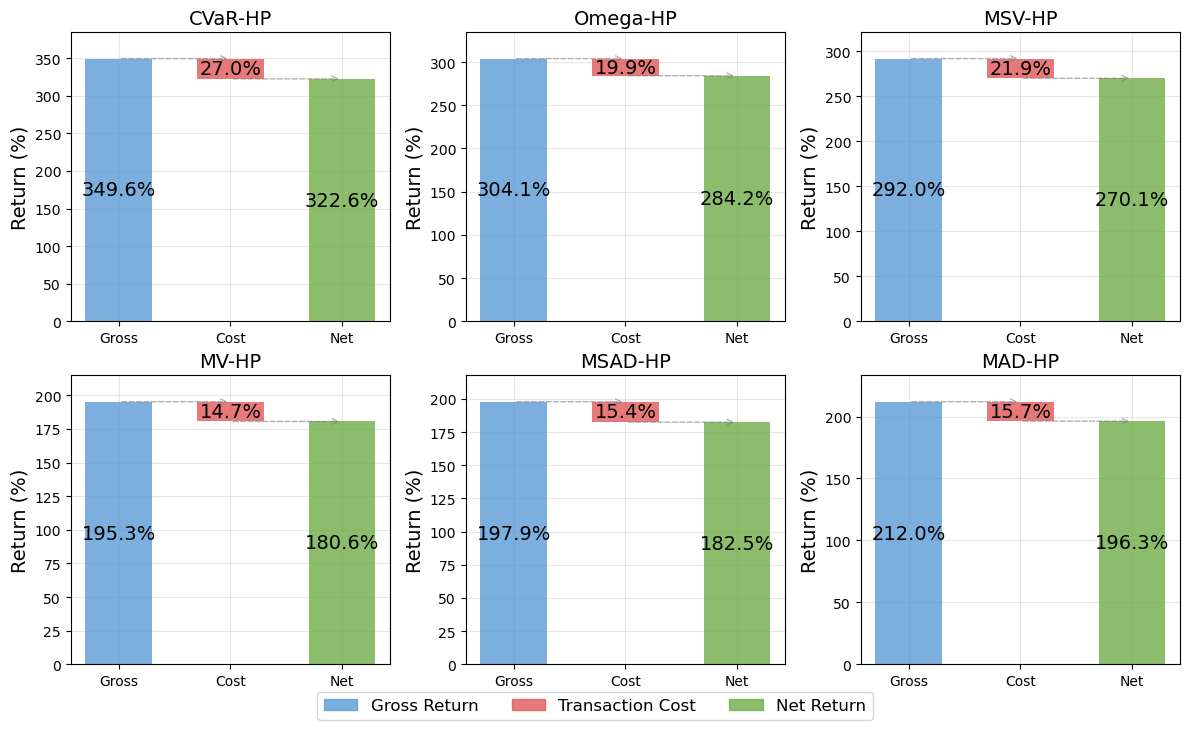

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

def create_waterfall_chart():
    """
    创建瀑布图展示六个模型HP版本的收益递减过程 (Gross → Cost → Net)
    """
    
    # 读取数据
    try:
        # 带成本的数据（净收益）portfolio_daily_returns0.05.csv
        cost_df = pd.read_csv('portfolio_daily_returns0.05.csv')
        cost_df['date'] = pd.to_datetime(cost_df['date'])
        
        # 不带成本的数据（毛收益）
        no_cost_df = pd.read_csv('portfolio_daily_returns.csv')
        no_cost_df['date'] = pd.to_datetime(no_cost_df['date'])
        
        print("✅ 成功读取数据文件")
        
    except FileNotFoundError as e:
        print(f"❌ 未找到数据文件: {e}")
        return None
    
    # 合并数据
    merged_df = pd.merge(cost_df, no_cost_df, on='date', how='inner', suffixes=('_with_cost', '_no_cost'))
    
    # 定义六个模型的HP版本
    models = ['CVaR', 'Omega', 'MSV', 'MV', 'MSAD', 'MAD']
    
    # 计算每个模型的累计收益率
    waterfall_data = []
    
    for model in models:
        # 列名
        net_col = f'{model}_Integrated_with_cost'  # 净收益
        gross_col = f'{model}_Integrated_no_cost'  # 毛收益
        
        if net_col in merged_df.columns and gross_col in merged_df.columns:
            # 计算累计收益率
            net_returns = merged_df[net_col]
            gross_returns = merged_df[gross_col]
            
            # 确保数据长度一致
            # min_length = min(len(net_returns), len(gross_returns))
            min_length = len(net_returns)
            if min_length > 0:
                # net_returns = net_returns.iloc[:min_length]
                # gross_returns = gross_returns.iloc[:min_length]
                
                # 计算累计收益率
                gross_cumulative = ((1 + gross_returns).cumprod() - 1).iloc[-1]
                net_cumulative = ((1 + net_returns).cumprod() - 1).iloc[-1]

                cost_impact = gross_cumulative - net_cumulative
                
                waterfall_data.append({
                    'Model': model,
                    'Gross': gross_cumulative * 100,  # 转换为百分比
                    'Cost': cost_impact * 100,
                    'Net': net_cumulative * 100
                })
                
                print(f"{model}: Gross={gross_cumulative:.4f}, Cost={cost_impact:.4f}, Net={net_cumulative:.4f}")
            else:
                print(f"  警告: {model} 无有效数据")
        else:
            print(f"  警告: 找不到 {model} 的数据列")
    
    if not waterfall_data:
        print("❌ 没有找到有效的数据")
        return None
    
    # 转换为DataFrame
    df_waterfall = pd.DataFrame(waterfall_data)
    
    # 创建瀑布图
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    # 设置颜色
    colors = {
        'Gross': '#5B9BD5',    # 蓝色
        'Cost': '#E15759',     # 红色
        'Net': '#70AD47'       # 绿色
    }
    
    for i, model in enumerate(models):
        ax = axes[i]
        
        if model in df_waterfall['Model'].values:
            model_data = df_waterfall[df_waterfall['Model'] == model].iloc[0]
            
            gross_val = model_data['Gross']
            cost_val = model_data['Cost']
            net_val = model_data['Net']
            
            # 绘制柱状图
            x_positions = [0, 1, 2]
            labels = ['Gross', 'Cost', 'Net']
            
            # Gross柱子
            ax.bar(0, gross_val, color=colors['Gross'], alpha=0.8, width=0.6)
            ax.text(0, gross_val/2, f'{gross_val:.1f}%', ha='center', va='center', 
                   color='black', fontsize=14)
            
            # Cost柱子（从Gross的顶部开始向下）
            ax.bar(1, cost_val, bottom=gross_val-cost_val, color=colors['Cost'], 
                  alpha=0.8, width=0.6)
            ax.text(1, gross_val - cost_val/2, f'{cost_val:.1f}%', ha='center', va='center', 
                   color='black', fontsize=14)
            
            # Net柱子
            ax.bar(2, net_val, color=colors['Net'], alpha=0.8, width=0.6)
            ax.text(2, net_val/2, f'{net_val:.1f}%', ha='center', va='center', 
                    color='black', fontsize=14)
            
            # 添加连接线（虚线箭头）
            # Gross到Cost的连接线
            ax.annotate('', xy=(1, gross_val), xytext=(0, gross_val),
                       arrowprops=dict(arrowstyle='->', linestyle='--', 
                                     color='gray', alpha=0.6))
            
            # Cost到Net的连接线
            ax.annotate('', xy=(2, net_val), xytext=(1, net_val),
                       arrowprops=dict(arrowstyle='->', linestyle='--', 
                                     color='gray', alpha=0.6))
            
            # 设置标签和标题
            ax.set_xticks(x_positions)
            ax.set_xticklabels(labels)
            ax.set_title(f'{model}-HP', fontsize=14)
            ax.set_ylabel('Return (%)', fontsize=14)
            
            # 设置y轴范围
            y_max = max(gross_val, net_val) * 1.1
            y_min = min(0, net_val * 0.9)
            ax.set_ylim(y_min, y_max)
            
            # 网格
            ax.grid(True, alpha=0.3)
            ax.set_axisbelow(True)
        else:
            ax.text(0.5, 0.5, f'No data for {model}', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{model}', fontsize=14)
    
    # 添加图例
    legend_elements = [
        mpatches.Patch(color=colors['Gross'], alpha=0.8, label='Gross Return'),
        mpatches.Patch(color=colors['Cost'], alpha=0.8, label='Transaction Cost'),
        mpatches.Patch(color=colors['Net'], alpha=0.8, label='Net Return')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
              bbox_to_anchor=(0.5,0.03), fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, bottom=0.11)
    
    plt.show()
    
    return df_waterfall

# 运行函数
if __name__ == "__main__":
    print("创建瀑布图...")
    
    # 创建分面瀑布图
    waterfall_data = create_waterfall_chart()

月度的

Creating Horizontal Monthly Excess Returns Box Plot...
✅ Successfully loaded monthly excess returns data
  MV-HP: 60 months of data
  MSV-HP: 60 months of data
  MAD-HP: 60 months of data
  MSAD-HP: 60 months of data
  Omega-HP: 60 months of data
  CVaR-HP: 60 months of data


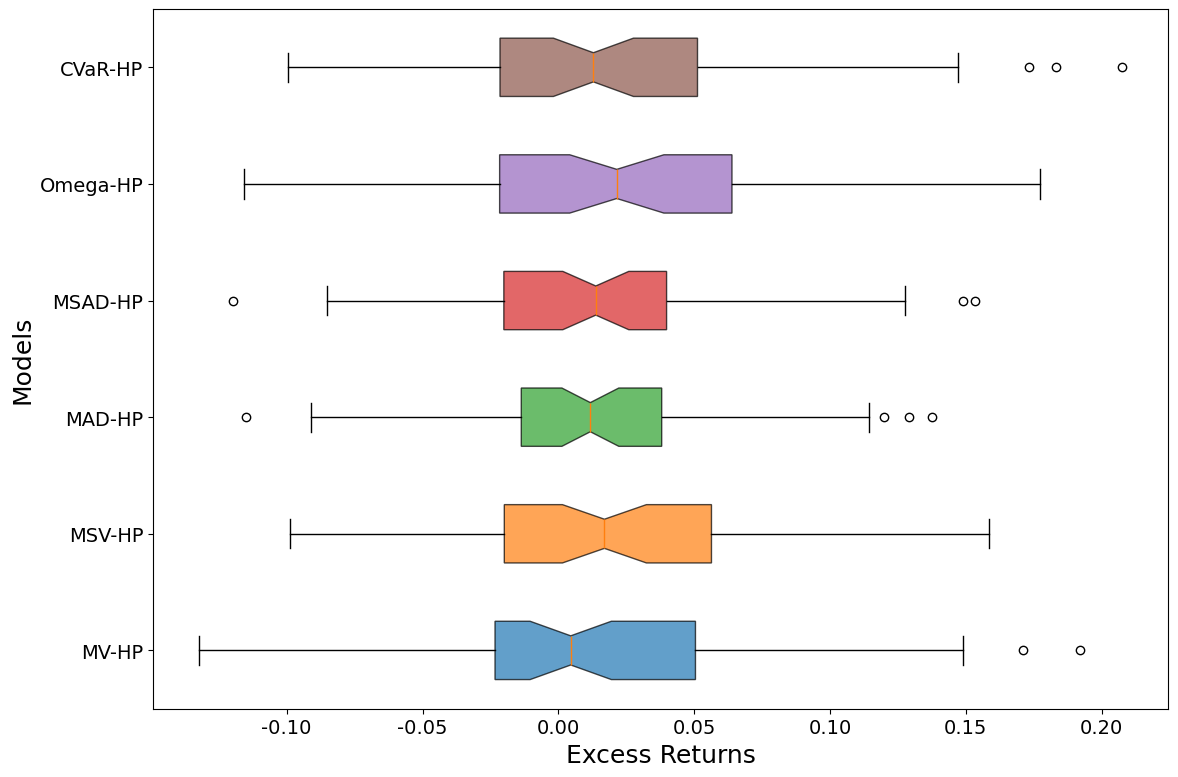


✅ Horizontal box plot saved as: Monthly_BoxPlot_Horizontal_EN.png

Horizontal Box Plot Analysis Complete!


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set English font and larger font sizes
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

def create_boxplot():
    """
    Create horizontal box plot visualization for monthly excess returns of six models
    """
    # Load monthly excess returns data
    try:
        df = pd.read_csv('Monthly_Excess_Returns0.05.csv')
        print("✅ Successfully loaded monthly excess returns data")
    except FileNotFoundError:
        print("❌ Monthly_Excess_Returns0.05.csv file not found")
        return None
    
    # Define model names and corresponding column names
    model_mapping = {
        'MV-HP': 'MV-HP_monthly_excess',
        'MSV-HP': 'MSV-HP_monthly_excess', 
        'MAD-HP': 'MAD-HP_monthly_excess',
        'MSAD-HP': 'MSAD-HP_monthly_excess',
        'Omega-HP': 'Omega-HP_monthly_excess',
        'CVaR-HP': 'CVaR-HP_monthly_excess'
    }
    
    # Define specified colors for each model
    model_colors = {
        'MV-HP': '#1f77b4',
        'MSV-HP': '#ff7f0e',
        'MAD-HP': '#2ca02c',
        'MSAD-HP': '#d62728',
        'Omega-HP': '#9467bd',
        'CVaR-HP': '#8c564b'
    }
    
    # Extract data
    model_data = {}
    model_names = ['MV-HP', 'MSV-HP', 'MAD-HP', 'MSAD-HP', 'Omega-HP', 'CVaR-HP']
    
    for model_name in model_names:
        col_name = model_mapping[model_name]
        if col_name in df.columns:
            # Remove missing values
            model_data[model_name] = df[col_name].dropna().values
            print(f"  {model_name}: {len(model_data[model_name])} months of data")
        else:
            print(f"Warning: Column {col_name} not found")
    
    if not model_data:
        print("❌ No valid model data found")
        return None
    
    # Prepare valid data
    valid_models = [name for name in model_names if name in model_data]
    valid_colors = [model_colors[name] for name in valid_models]
    
    # Create horizontal box plot
    plt.figure(figsize=(12, 8))
    
    box_data = [model_data[name] for name in valid_models]
    box_labels = valid_models
    
    # Create horizontal boxplot with vert=False
    bp = plt.boxplot(box_data, labels=box_labels, patch_artist=True, notch=True, vert=False)
    
    # Apply specified colors
    for patch, color in zip(bp['boxes'], valid_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Set labels (transposed)
    plt.xlabel('Excess Returns', fontsize=18)
    plt.ylabel('Models', fontsize=18)
    
    # Remove grid
    plt.grid(False)
    
    # Adjust layout and font sizes
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    plt.tight_layout()
    plt.savefig('Monthly_BoxPlot_Horizontal_EN.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Horizontal box plot saved as: Monthly_BoxPlot_Horizontal_EN.png")
    return True

# Run analysis
if __name__ == "__main__":
    print("Creating Horizontal Monthly Excess Returns Box Plot...")
    print("="*50)
    success = create_boxplot()
    if success:
        print("\n" + "="*50)
        print("Horizontal Box Plot Analysis Complete!")
        print("="*50)
    else:
        print("Analysis failed, please check data files")

Starting monthly returns bar chart plotting...
✅ Successfully loaded monthly excess returns data
Found 6 HP models: ['CVaR-HP', 'Omega-HP', 'MSV-HP', 'MV-HP', 'MSAD-HP', 'MAD-HP']
Data period: 2020-2024
✅ Charts saved:
   • Monthly_Returns_HP_Models_EN.png
   • Monthly_Returns_HP_Models_EN.pdf


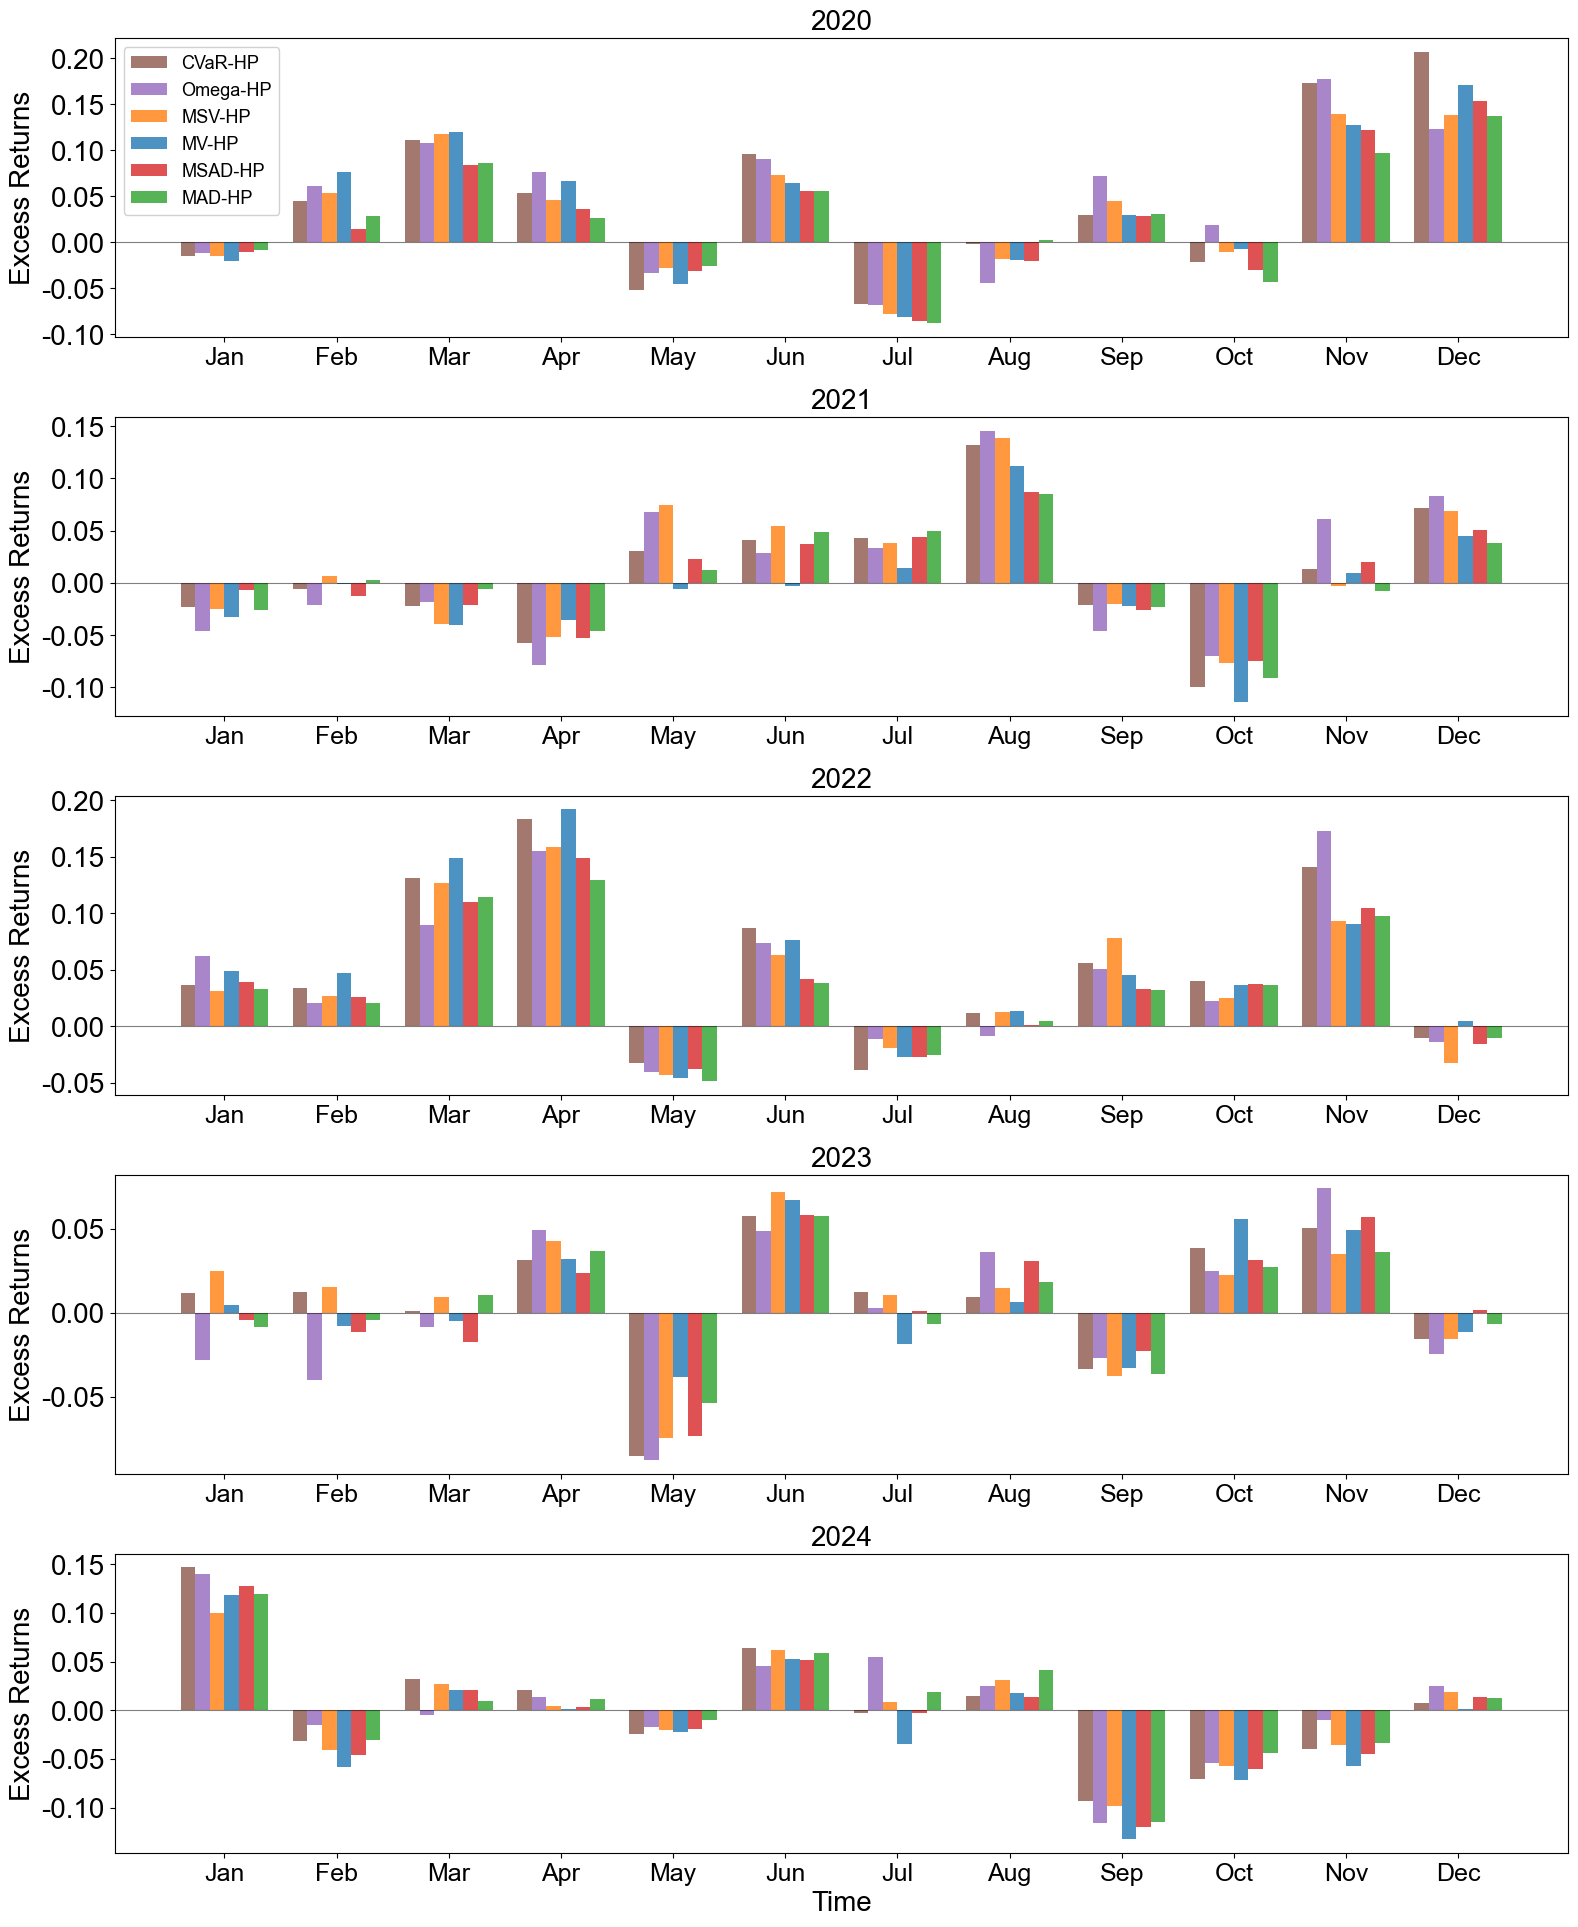

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import seaborn as sns
from matplotlib.ticker import MultipleLocator
# Set English font
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

def plot_monthly_returns_bar_charts():
    """
    Plot monthly returns bar charts for HP models only
    """
    
    # Load data
    try:
        df = pd.read_csv('Monthly_Excess_Returns0.05.csv')
        print("✅ Successfully loaded monthly excess returns data")
    except FileNotFoundError:
        print("❌ Monthly_Excess_Returns.csv file not found")
        return
    
    # Parse year-month data
    df['year_month'] = pd.to_datetime(df['year_month'])
    df['year'] = df['year_month'].dt.year
    df['month'] = df['year_month'].dt.month
    
    # Manually specify model order as requested
    model_names = ['CVaR-HP', 'Omega-HP', 'MSV-HP', 'MV-HP', 'MSAD-HP', 'MAD-HP']
    
    # Verify that these models exist in the data
    available_columns = [col for col in df.columns if col.endswith('_monthly_excess')]
    available_models = [col.replace('_monthly_excess', '') for col in available_columns if '-HP' in col]
    
    # Filter to only include models that exist in the data
    existing_models = [model for model in model_names if f'{model}_monthly_excess' in df.columns]
    
    if not existing_models:
        print("❌ No HP models found in the data")
        return
    
    model_names = existing_models
    
    print(f"Found {len(model_names)} HP models: {model_names}")
    print(f"Data period: {df['year'].min()}-{df['year'].max()}")
    
    # Get all years
    years = sorted(df['year'].unique())
    
    # Color configuration for 6 HP models (keeping same colors)
    model_colors = {
        'MV-HP': '#1f77b4',
        'MSV-HP': '#ff7f0e',
        'MAD-HP': '#2ca02c',
        'MSAD-HP': '#d62728',
        'Omega-HP': '#9467bd',
        'CVaR-HP': '#8c564b'
    }
    
    # Create subplots (n_years rows, 1 column)
    n_years = len(years)
    fig, axes = plt.subplots(n_years, 1, figsize=(16, 4 * n_years))
    
    # If only one year of data, ensure axes is a list
    if n_years == 1:
        axes = [axes]
    
    # Month names
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Calculate bar width
    n_models = len(model_names)
    width = 0.13  # Fixed width for 6 models
    
    # Draw subplot for each year
    for i, year in enumerate(years):
        ax = axes[i]
        year_data = df[df['year'] == year].copy()
        year_data = year_data.sort_values('month')
        
        # Set bar positions
        x = np.arange(12)  # 12 months
        
        # Draw bars for each HP model (in the specified order)
        for j, model_name in enumerate(model_names):
            col_name = f'{model_name}_monthly_excess'
            
            # Create array of 12 months data, fill missing months with 0
            monthly_returns = np.zeros(12)
            for _, row in year_data.iterrows():
                month_idx = int(row['month']) - 1  # Convert to 0-11 index
                if col_name in row and not pd.isna(row[col_name]):
                    monthly_returns[month_idx] = row[col_name]
            
            # Calculate offset to center 6 bars
            offset = (j - 2.5) * width  # Center align 6 bars
            
            # Draw bars without black edges
            bars = ax.bar(x + offset, monthly_returns, width, 
                         label=model_name, color=model_colors[model_name], 
                         alpha=0.8, edgecolor='none')  # 去掉黑边框
        
        # Set subplot properties
        # 只有最后一个子图显示横轴标签
        if i == len(years) - 1:
            ax.set_xlabel('Time', fontsize=20)  # 修改横轴标签

        ax.set_ylabel('Excess Returns', fontsize=20)  # 修改纵轴标签
        ax.set_title(f'{year}', fontsize=20)  # 只显示年份

        # Set x-axis
        ax.set_xticks(x)
        ax.set_xticklabels(month_names, fontsize=18)
        
        # 设置y轴刻度字体大小
        ax.tick_params(axis='y', labelsize=20)
        ax.yaxis.set_major_locator(MultipleLocator(0.05))

        # 去掉网格
        ax.grid(False)
        
        # Add zero line
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
        
        # 图例在图中 (只在第一个子图显示，模型顺序已按要求排列)
        if i == 0:
            ax.legend(loc='upper left', fontsize=13, framealpha=0.9)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  # 不需要为图例留空间了
    
    # Save plots
    plt.savefig('Monthly_Returns_HP_Models_EN.png', dpi=300, bbox_inches='tight')
    plt.savefig('Monthly_Returns_HP_Models_EN.pdf', bbox_inches='tight')
    
    print("✅ Charts saved:")
    print("   • Monthly_Returns_HP_Models_EN.png")
    print("   • Monthly_Returns_HP_Models_EN.pdf")
    
    plt.show()

def main():
    """
    Main function: run all plotting and analysis
    """
    print("Starting monthly returns bar chart plotting...")
    print("="*60)
    
    # 1. Plot main monthly bar charts
    plot_monthly_returns_bar_charts()

if __name__ == "__main__":
    main()

In [18]:
import pandas as pd
import os

def extract_hp_model_data(input_file='Monthly_Excess_Returns0.05.csv', output_file='HP_Model_Monthly_Data0.05.csv'):
    """
    从Monthly_Excess_Returns0.05.csv中提取HP模型和日期数据
    """
    
    if not os.path.exists(input_file):
        print(f"错误：文件 '{input_file}' 不存在")
        return None
    
    # 读取数据
    df = pd.read_csv(input_file, encoding='utf-8-sig')
    
    # 找日期列
    date_columns = []
    for col in df.columns:
        col_lower = str(col).lower()
        if any(keyword in col_lower for keyword in ['date', '日期', 'time', '时间']):
            date_columns.append(col)
    
    if not date_columns:
        date_columns = [df.columns[0]]  # 默认第一列为日期
    
    # 找HP列
    hp_columns = [col for col in df.columns if 'HP' in str(col)]
    
    if not hp_columns:
        print("未找到HP相关列")
        return None
    
    # 保留需要的列
    columns_to_keep = date_columns + hp_columns
    result_df = df[columns_to_keep].copy()
    
    # 保存文件
    result_df.to_csv(output_file, index=False, encoding='utf-8-sig')
    print(f"数据已保存到: {output_file}")
    
    return result_df

if __name__ == "__main__":
    extract_hp_model_data()

数据已保存到: HP_Model_Monthly_Data0.05.csv


In [19]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon, friedmanchisquare
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

def load_and_prepare_data():
    """加载和准备数据"""
    try:
        df = pd.read_csv('HP_Model_Monthly_Data0.05.csv')
        print("✅ 成功加载数据")
        
        # 获取模型列
        model_columns = [col for col in df.columns if col.endswith('_monthly_excess')]
        model_names = [col.replace('_monthly_excess', '') for col in model_columns]
        
        # 准备干净的配对数据
        df_clean = df[['year_month'] + model_columns].dropna()
        
        return df_clean, model_names, model_columns
    except FileNotFoundError:
        print("❌ 未找到数据文件")
        return None, None, None

def friedman_test(df, model_names, model_columns):
    """进行Friedman检验"""
    print("\n" + "="*80)
    print("Friedman检验 (多个相关样本的非参数检验)")
    print("="*80)
    
    # 准备完整配对数据
    complete_data = df[model_columns].dropna()
    n_complete = len(complete_data)
    
    if n_complete < 3:
        print(f"❌ 完整配对数据不足 (n={n_complete}，需要至少3个观测)")
        return None
    
    if len(model_columns) < 3:
        print(f"❌ 模型数量不足 (k={len(model_columns)}，需要至少3个模型)")
        return None
    
    try:
        # 进行Friedman检验
        statistic, p_value = friedmanchisquare(*[complete_data[col] for col in model_columns])
        
        print(f"样本数 (n): {n_complete}")
        print(f"模型数 (k): {len(model_columns)}")
        print(f"自由度: {len(model_columns) - 1}")
        print(f"Friedman统计量: {statistic:.4f}")
        print(f"P值: {p_value:.8f}")
        
        if p_value < 0.05:
            print(f"结论: 拒绝原假设 (p < 0.05)，至少有一个模型的分布显著不同")
        else:
            print(f"结论: 接受原假设 (p ≥ 0.05)，所有模型的分布无显著差异")
        
        # 计算平均秩
        print(f"\n各模型的平均秩:")
        ranks = complete_data.rank(axis=1, method='average')
        mean_ranks = ranks.mean()
        
        rank_table = pd.DataFrame({
            '模型': model_names,
            '平均秩': [mean_ranks[col] for col in model_columns]
        }).sort_values('平均秩')
        
        print(rank_table.to_string(index=False, float_format='%.4f'))
        
        return {
            'n_samples': n_complete,
            'n_groups': len(model_columns),
            'statistic': statistic,
            'p_value': p_value,
            'significant': p_value < 0.05,
            'mean_ranks': mean_ranks.to_dict()
        }
        
    except Exception as e:
        print(f"❌ Friedman检验失败: {e}")
        return None

def wilcoxon_signed_rank_tests(df, model_names, model_columns):
    """进行所有两两配对的Wilcoxon符号秩检验"""
    print("\n" + "="*80)
    print("Wilcoxon符号秩检验 (配对样本)")
    print("="*80)
    
    results = []
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            model1, model2 = model_names[i], model_names[j]
            
            # 使用配对数据
            paired_data = df[[model_columns[i], model_columns[j]]].dropna()
            
            if len(paired_data) < 6:
                results.append({
                    'Model1': model1,
                    'Model2': model2,
                    'N_pairs': len(paired_data),
                    'Statistic': np.nan,
                    'P_Value': np.nan,
                    'Status': '数据不足'
                })
                continue
                
            try:
                # 进行Wilcoxon符号秩检验
                statistic, p_value = wilcoxon(paired_data.iloc[:, 0], 
                                            paired_data.iloc[:, 1], 
                                            alternative='two-sided')
                
                results.append({
                    'Model1': model1,
                    'Model2': model2,
                    'N_pairs': len(paired_data),
                    'Statistic': statistic,
                    'P_Value': p_value,
                    'Status': '成功'
                })
                
            except ValueError as e:
                # 处理所有差值为0的情况
                if "zero_method" in str(e) or "all zero" in str(e).lower():
                    results.append({
                        'Model1': model1,
                        'Model2': model2,
                        'N_pairs': len(paired_data),
                        'Statistic': np.nan,
                        'P_Value': 1.0,  # 如果所有差值都为0，p值为1
                        'Status': '无差异'
                    })
                else:
                    results.append({
                        'Model1': model1,
                        'Model2': model2,
                        'N_pairs': len(paired_data),
                        'Statistic': np.nan,
                        'P_Value': np.nan,
                        'Status': f'失败: {e}'
                    })
            except Exception as e:
                results.append({
                    'Model1': model1,
                    'Model2': model2,
                    'N_pairs': len(paired_data),
                    'Statistic': np.nan,
                    'P_Value': np.nan,
                    'Status': f'失败: {e}'
                })
    
    # 以表格形式显示结果
    print("\nWilcoxon符号秩检验结果:")
    print("-" * 90)
    
    results_df = pd.DataFrame(results)
    
    # 格式化显示
    display_df = results_df.copy()
    display_df['模型对比'] = display_df['Model1'] + ' vs ' + display_df['Model2']
    display_df['配对数'] = display_df['N_pairs']
    display_df['W统计量'] = display_df['Statistic'].apply(lambda x: f'{x:.2f}' if not np.isnan(x) else 'N/A')
    display_df['P值'] = display_df['P_Value'].apply(lambda x: f'{x:.6f}' if not np.isnan(x) else 'N/A')
    display_df['状态'] = display_df['Status']
    
    # 选择要显示的列
    display_cols = ['模型对比', '配对数', 'W统计量', 'P值', '状态']
    print(display_df[display_cols].to_string(index=False))
    
    return results

def apply_holm_correction(results):
    """应用Holm多重检验校正"""
    print("\n" + "="*80)
    print("Holm多重检验校正")
    print("="*80)
    
    # 收集有效的p值
    valid_results = []
    p_values = []
    
    for result in results:
        if not np.isnan(result['P_Value']) and result['Status'] in ['成功', '无差异']:
            valid_results.append(result)
            p_values.append(result['P_Value'])
    
    if len(p_values) == 0:
        print("没有有效的p值进行校正")
        return results
    
    print(f"有效检验数: {len(p_values)}")
    print(f"原始显著检验数 (p<0.05): {sum(p < 0.05 for p in p_values)}")
    
    # 应用Holm校正
    reject, p_corrected, alpha_sidak, alpha_bonf = multipletests(p_values, method='holm')
    
    # 更新结果
    corrected_results = []
    valid_idx = 0
    
    for result in results:
        new_result = result.copy()
        
        if not np.isnan(result['P_Value']) and result['Status'] in ['成功', '无差异']:
            new_result['P_Value_Corrected'] = p_corrected[valid_idx]
            new_result['Significant_Original'] = result['P_Value'] < 0.05
            new_result['Significant_Corrected'] = reject[valid_idx]
            valid_idx += 1
        else:
            new_result['P_Value_Corrected'] = np.nan
            new_result['Significant_Original'] = False
            new_result['Significant_Corrected'] = False
        
        corrected_results.append(new_result)
    
    # 显示校正结果
    significant_original = sum(1 for r in corrected_results if r['Significant_Original'])
    significant_corrected = sum(1 for r in corrected_results if r['Significant_Corrected'])
    
    print(f"Holm校正后显著检验数: {significant_corrected}")
    
    # 以表格形式显示校正前后的对比
    print(f"\n校正前后对比表:")
    print("-" * 95)
    
    comparison_data = []
    for result in corrected_results:
        if not np.isnan(result['P_Value']):
            comparison_data.append({
                '模型对比': f"{result['Model1']} vs {result['Model2']}",
                '原始P值': f"{result['P_Value']:.6f}",
                '校正P值': f"{result['P_Value_Corrected']:.6f}",
                '原始显著': "是" if result['Significant_Original'] else "否",
                '校正显著': "是" if result['Significant_Corrected'] else "否"
            })
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    
    # 显示Holm校正后仍显著的检验
    print(f"\nHolm校正后仍显著的检验 (p<0.05):")
    significant_tests = [r for r in corrected_results if r['Significant_Corrected']]
    
    if significant_tests:
        for result in significant_tests:
            model_pair = f"{result['Model1']} vs {result['Model2']}"
            print(f"  ✓ {model_pair}: 原始p={result['P_Value']:.6f}, 校正p={result['P_Value_Corrected']:.6f}")
    else:
        print("  无检验在Holm校正后仍然显著")
    
    return corrected_results

def generate_summary_statistics(df, model_names, model_columns, results, friedman_result):
    """生成汇总统计"""
    print("\n" + "="*80)
    print("汇总统计")
    print("="*80)
    
    # 基础统计表格
    print("各模型基础统计:")
    print("-" * 85)
    
    stats_data = []
    for i, (model, col) in enumerate(zip(model_names, model_columns)):
        data = df[col].dropna()
        stats_data.append({
            '模型': model,
            '观测数': len(data),
            '均值': f"{data.mean():.6f}",
            '中位数': f"{data.median():.6f}",
            '标准差': f"{data.std():.6f}",
            '偏度': f"{data.skew():.4f}",
            '峰度': f"{data.kurtosis():.4f}"
        })
    
    stats_df = pd.DataFrame(stats_data)
    print(stats_df.to_string(index=False))
    
    # 检验结果汇总
    valid_results = [r for r in results if not np.isnan(r['P_Value'])]
    total_tests = len(valid_results)
    significant_original = sum(1 for r in valid_results if r['Significant_Original'])
    significant_corrected = sum(1 for r in valid_results if r['Significant_Corrected'])
    
    print(f"\n检验结果汇总:")
    print("-" * 50)
    
    # Friedman检验结果
    if friedman_result:
        print(f"Friedman检验: {'显著' if friedman_result['significant'] else '不显著'} (p={friedman_result['p_value']:.6f})")
    else:
        print(f"Friedman检验: 未执行")
    
    print(f"总的成对检验数: {total_tests}")
    print(f"原始显著数 (p<0.05): {significant_original} ({significant_original/total_tests*100:.1f}%)")
    print(f"Holm校正后显著数: {significant_corrected} ({significant_corrected/total_tests*100:.1f}%)")
    
    if significant_corrected > 0:
        print(f"\n🔍 发现 {significant_corrected} 对模型存在显著差异")
    else:
        print(f"\n❌ 经过Holm校正后，没有发现显著的模型差异")

def save_results(results, df, model_names, model_columns, friedman_result):
    """保存结果"""
    if not results:
        print("没有结果可保存")
        return
    
    # 创建结果DataFrame
    results_df = pd.DataFrame(results)
    
    # 保存CSV文件
    results_df.to_csv('Wilcoxon_Friedman_Results0.05.csv', index=False, encoding='utf-8-sig')
    
    # 保存Excel文件
    with pd.ExcelWriter('Wilcoxon_Friedman_Results0.05.xlsx', engine='openpyxl') as writer:
        # Wilcoxon检验结果
        results_df.to_excel(writer, sheet_name='Wilcoxon_Results', index=False)
        
        # Friedman检验结果
        if friedman_result:
            friedman_df = pd.DataFrame([{
                'Test': 'Friedman',
                'N_Samples': friedman_result['n_samples'],
                'N_Groups': friedman_result['n_groups'],
                'Statistic': friedman_result['statistic'],
                'P_Value': friedman_result['p_value'],
                'Significant': friedman_result['significant']
            }])
            friedman_df.to_excel(writer, sheet_name='Friedman_Result', index=False)
            
            # 平均秩结果
            ranks_data = []
            for model, col in zip(model_names, model_columns):
                if col in friedman_result['mean_ranks']:
                    ranks_data.append({
                        'Model': model,
                        'Mean_Rank': friedman_result['mean_ranks'][col]
                    })
            if ranks_data:
                ranks_df = pd.DataFrame(ranks_data).sort_values('Mean_Rank')
                ranks_df.to_excel(writer, sheet_name='Mean_Ranks', index=False)
        
        # 显著性结果
        significant_df = results_df[results_df['Significant_Corrected'] == True]
        if not significant_df.empty:
            significant_df.to_excel(writer, sheet_name='Significant_Results', index=False)
        
        # 模型基础统计
        stats_data = []
        for i, (model, col) in enumerate(zip(model_names, model_columns)):
            data = df[col].dropna()
            stats_data.append({
                'Model': model,
                'N_Observations': len(data),
                'Mean': data.mean(),
                'Median': data.median(),
                'Std': data.std(),
                'Min': data.min(),
                'Max': data.max(),
                'Skewness': data.skew(),
                'Kurtosis': data.kurtosis()
            })
        
        stats_df = pd.DataFrame(stats_data)
        stats_df.to_excel(writer, sheet_name='Model_Statistics', index=False)
    
    print(f"\n✅ 结果已保存:")
    print(f"   • Wilcoxon_Friedman_Results0.05.csv")
    print(f"   • Wilcoxon_Friedman_Results0.05.xlsx")

def main():
    """主函数"""
    print("Friedman检验 + Wilcoxon符号秩检验 + Holm校正")
    print("="*80)
    
    # 加载数据
    df, model_names, model_columns = load_and_prepare_data()
    if df is None:
        return
    
    print(f"分析模型: {model_names}")
    print(f"有效观测数: {len(df)}")
    print(f"两两比较数: {len(model_names) * (len(model_names) - 1) // 2}")
    
    # 首先进行Friedman检验
    friedman_result = friedman_test(df, model_names, model_columns)
    
    # 进行Wilcoxon符号秩检验
    results = wilcoxon_signed_rank_tests(df, model_names, model_columns)
    
    # 应用Holm校正
    corrected_results = apply_holm_correction(results)
    
    # 生成汇总统计
    generate_summary_statistics(df, model_names, model_columns, corrected_results, friedman_result)
    
    # 保存结果
    save_results(corrected_results, df, model_names, model_columns, friedman_result)
    
    print(f"\n" + "="*80)
    print("分析完成!")
    print("说明:")
    print("• Friedman检验: 检验多个相关样本是否来自相同分布")
    print("• Wilcoxon符号秩检验: 检验两个相关样本的差异")
    print("• Holm校正: 控制多重比较的家族错误率(FWER)")
    print("="*80)

if __name__ == "__main__":
    main()

Friedman检验 + Wilcoxon符号秩检验 + Holm校正
✅ 成功加载数据
分析模型: ['MV-HP', 'MSV-HP', 'MAD-HP', 'MSAD-HP', 'Omega-HP', 'CVaR-HP']
有效观测数: 60
两两比较数: 15

Friedman检验 (多个相关样本的非参数检验)
样本数 (n): 60
模型数 (k): 6
自由度: 5
Friedman统计量: 13.6762
P值: 0.01780255
结论: 拒绝原假设 (p < 0.05)，至少有一个模型的分布显著不同

各模型的平均秩:
      模型    平均秩
 MSAD-HP 3.0333
   MV-HP 3.1500
  MAD-HP 3.2667
Omega-HP 3.7167
  MSV-HP 3.8500
 CVaR-HP 3.9833

Wilcoxon符号秩检验 (配对样本)

Wilcoxon符号秩检验结果:
------------------------------------------------------------------------------------------
               模型对比  配对数   W统计量       P值 状态
    MV-HP vs MSV-HP   60 691.00 0.099148 成功
    MV-HP vs MAD-HP   60 847.00 0.616660 成功
   MV-HP vs MSAD-HP   60 853.00 0.648088 成功
  MV-HP vs Omega-HP   60 733.00 0.180307 成功
   MV-HP vs CVaR-HP   60 565.00 0.009979 成功
   MSV-HP vs MAD-HP   60 610.00 0.024750 成功
  MSV-HP vs MSAD-HP   60 561.00 0.009160 成功
 MSV-HP vs Omega-HP   60 853.00 0.648088 成功
  MSV-HP vs CVaR-HP   60 844.00 0.601201 成功
  MAD-HP vs MSAD-HP   60 912.00 0.982380 成功

开始绘制Integrated vs Original累计收益率差值图...
✅ 成功加载数据
CVaR: 最终差值 = 2.0393 (203.93%)
MSV: 最终差值 = 1.8720 (187.20%)
Omega: 最终差值 = 1.5027 (150.27%)
MAD: 最终差值 = 1.2332 (123.32%)
MSAD: 最终差值 = 1.1392 (113.92%)
MV: 最终差值 = 0.9326 (93.26%)


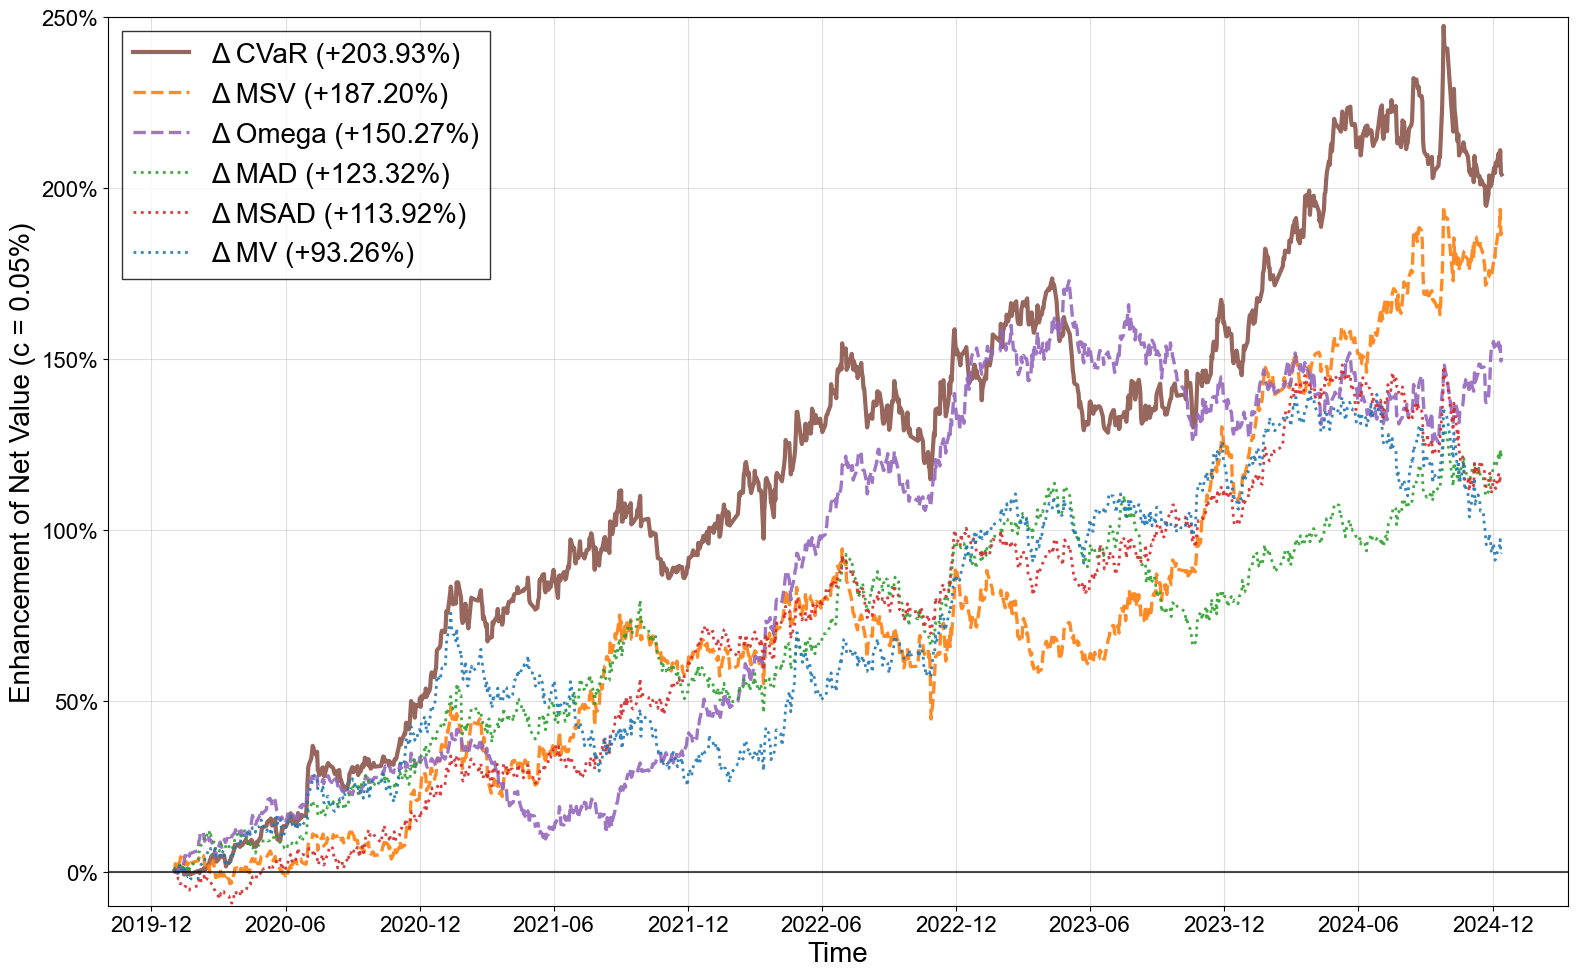


✅ 图片已保存为: Integrated_vs_Original_Difference0.05.png

统计摘要 (按最终差值排序):
--------------------------------------------------
Model Final_Difference Max_Difference Min_Difference Mean_Difference Std_Difference
 CVaR           2.0393         2.4739        -0.0090          1.1755         0.6219
  MSV           1.8720         1.9458        -0.0358          0.7301         0.5187
Omega           1.5027         1.7284        -0.0056          0.8667         0.5663
  MAD           1.2332         1.3043         0.0032          0.6735         0.3266
 MSAD           1.1392         1.4823        -0.0926          0.6916         0.4501
   MV           0.9326         1.4032        -0.0242          0.6987         0.4035

✅ 统计数据已保存为: Integrated_Original_Difference_Stats0.05.csv

改进效果分析 (按最终差值排序):
CVaR    : ✓ 改进 | 差值: +2.0393 (+93.24%)
MSV     : ✓ 改进 | 差值: +1.8720 (+102.35%)
Omega   : ✓ 改进 | 差值: +1.5027 (+64.23%)
MAD     : ✓ 改进 | 差值: +1.2332 (+71.29%)
MSAD    : ✓ 改进 | 差值: +1.1392 (+67.58%)
MV      : ✓ 改进 | 差

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

def plot_integrated_original_difference():
    """
    绘制六个模型的Integrated累计收益率减去Original累计收益率的差值图
    """
    
    # 设置更大的字体
    plt.rcParams.update({'font.size': 14})
    
    # 读取数据
    try:
        df = pd.read_csv('portfolio_daily_returns0.05.csv')
        df['date'] = pd.to_datetime(df['date'])
        print("✅ 成功加载数据")
    except FileNotFoundError:
        print("❌ 未找到 portfolio_daily_returns0.05.csv 文件")
        return
    
    # 定义六个模型
    models = ['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']
    
    # 首先计算所有模型的最终差值，用于排序
    model_final_diffs = []
    
    for model in models:
        integrated_col = f'{model}_Integrated'
        original_col = f'{model}_Original'
        
        # 检查列是否存在
        if integrated_col in df.columns and original_col in df.columns:
            # 计算累计收益率
            integrated_cumret = (1 + df[integrated_col]).cumprod() - 1
            original_cumret = (1 + df[original_col]).cumprod() - 1
            
            # 计算差值
            difference = integrated_cumret - original_cumret
            final_diff = difference.iloc[-1]
            
            model_final_diffs.append({
                'model': model,
                'final_diff': final_diff,
                'difference_series': difference
            })
    
    # 按最终差值从高到低排序
    model_final_diffs.sort(key=lambda x: x['final_diff'], reverse=True)
    
    # 设置图形
    plt.figure(figsize=(16, 10))
    
    # 定义指定的颜色映射
    model_colors = {
        'CVaR': '#8c564b',
        'Omega': '#9467bd', 
        'MSV': '#ff7f0e',
        'MAD': '#2ca02c',
        'MSAD': '#d62728',
        'MV': '#1f77b4'
    }
    
    # 定义线条样式，避免缠绕
    line_styles = ['-', '--', '--', ':', ':', ':']
    line_widths = [3.0, 2.4, 2.4, 2.0, 2.0, 2.0]
    
    # 按排序后的顺序绘制每个模型的差值曲线
    for i, model_data in enumerate(model_final_diffs):
        model = model_data['model']
        difference = model_data['difference_series']
        final_diff = model_data['final_diff']
        
        # 绘制曲线（图例使用新格式）
        plt.plot(df['date'], difference, 
                label=f'Δ {model} (+{final_diff*100:.2f}%)', 
                color=model_colors[model], 
                linewidth=line_widths[i], 
                linestyle=line_styles[i],
                alpha=0.9)
        
        # 打印最终差值
        print(f"{model}: 最终差值 = {final_diff:.4f} ({final_diff*100:.2f}%)")
    
    # 添加零线作为参考
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.7, linewidth=1.5)
    
    # 设置图形属性
    plt.xlabel('Time', fontsize=20)
    plt.ylabel('Enhancement of Net Value (c = 0.05%)', fontsize=20)
    
    # 设置图例（去掉立体效果）
    plt.legend(loc='upper left', fontsize=20, frameon=True, 
              fancybox=False, shadow=False, edgecolor='black')
    
    # 设置网格
    plt.grid(True, alpha=0.4, linestyle='-', linewidth=0.8)
    
    # 格式化x轴 - 每6个月显示一次，格式为2020-06, 2020-12等
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=[6, 12]))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    # 设置x轴刻度字体大小，如果能放下就不旋转
    plt.tick_params(axis='x', labelsize=16, rotation=0)
    plt.tick_params(axis='y', labelsize=16)
    
    # 设置y轴格式为整数百分比
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

    # 设置y轴范围（-100% 到 350%）
    plt.ylim(-0.1, 2.5)

    # 调整布局
    plt.tight_layout()
    
    # 保存图片
    plt.savefig('Integrated_vs_Original_Difference0.05.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n✅ 图片已保存为: Integrated_vs_Original_Difference0.05.png")

    # 计算统计信息
    print(f"\n统计摘要 (按最终差值排序):")
    print("-" * 50)
    
    stats_data = []
    for model_data in model_final_diffs:
        model = model_data['model']
        difference = model_data['difference_series']
        
        # 统计信息
        stats_data.append({
            'Model': model,
            'Final_Difference': f"{difference.iloc[-1]:.4f}",
            'Max_Difference': f"{difference.max():.4f}",
            'Min_Difference': f"{difference.min():.4f}",
            'Mean_Difference': f"{difference.mean():.4f}",
            'Std_Difference': f"{difference.std():.4f}"
        })
    
    # 显示统计表格
    if stats_data:
        stats_df = pd.DataFrame(stats_data)
        print(stats_df.to_string(index=False))
        
        # 保存统计数据
        stats_df.to_csv('Integrated_Original_Difference_Stats0.05.csv', index=False, encoding='utf-8-sig')
        print(f"\n✅ 统计数据已保存为: Integrated_Original_Difference_Stats0.05.csv")

def analyze_improvement_performance():
    """
    分析改进效果的表现（按最终差值排序）
    """
    
    # 读取数据
    try:
        df = pd.read_csv('portfolio_daily_returns0.05.csv')
        df['date'] = pd.to_datetime(df['date'])
    except FileNotFoundError:
        print("❌ 未找到数据文件")
        return
    
    models = ['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']
    
    # 计算所有模型的最终差值并排序
    model_improvements = []
    
    for model in models:
        integrated_col = f'{model}_Integrated'
        original_col = f'{model}_Original'
        
        if integrated_col in df.columns and original_col in df.columns:
            # 计算累计收益率
            integrated_cumret = (1 + df[integrated_col]).cumprod() - 1
            original_cumret = (1 + df[original_col]).cumprod() - 1
            
            final_integrated = integrated_cumret.iloc[-1]
            final_original = original_cumret.iloc[-1]
            improvement = final_integrated - final_original
            improvement_pct = (improvement / (final_original + 1)) * 100 if (final_original + 1) != 0 else 0
            
            model_improvements.append({
                'model': model,
                'improvement': improvement,
                'improvement_pct': improvement_pct
            })
    
    # 按改进程度排序
    model_improvements.sort(key=lambda x: x['improvement'], reverse=True)
    
    print(f"\n改进效果分析 (按最终差值排序):")
    print("="*60)
    
    positive_count = 0
    total_models = len(model_improvements)
    
    for model_data in model_improvements:
        model = model_data['model']
        improvement = model_data['improvement']
        improvement_pct = model_data['improvement_pct']
        
        status = "✓ 改进" if improvement > 0 else "✗ 下降"
        if improvement > 0:
            positive_count += 1
        
        print(f"{model:<8}: {status} | 差值: {improvement:+.4f} ({improvement_pct:+.2f}%)")
    
    print("-"*60)
    print(f"总结: {positive_count}/{total_models} 个模型的Integrated版本优于Original版本")
    if positive_count > total_models // 2:
        print("结论: 多数模型通过集成方法获得了改进")
    else:
        print("结论: 多数模型在集成后表现不如原始版本")

# 运行分析
if __name__ == "__main__":
    print("开始绘制Integrated vs Original累计收益率差值图...")
    print("="*60)
    
    # 绘制差值图
    plot_integrated_original_difference()
    
    # 分析改进效果
    analyze_improvement_performance()